# Notebook 3: Spectral Classification
This notebook aims to leverage the information acquired from the second notebook to build a spectral, pixel classifier so that we try to answer:

> How well does spectral information classify grains as bands are reduced?

## 0. Imports

In [ ]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk

import warnings
warnings.filterwarnings('ignore')

from hsi_utils import load_data, load_cube, build_foreground_mask_auto

from scipy.signal import find_peaks

from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.pipeline import make_pipeline

import math

from collections import Counter

from pathlib import Path

import re, os

from scipy.ndimage import (
    distance_transform_edt,
    sobel,
    label as connected_component_label,
    binary_dilation
)


## 1. Load Data

In [ ]:
train_files, valid_files, test_files, files_split = load_data(
    mode="direct",
    dataset_path=Path(
        "/mnt/c/Users/isaac/HSI_Dataset"
    ),
    varieties=("barley", "corn", "flax")
)

[OK] Found dataset: /mnt/c/Users/isaac/HSI_Dataset
[OK] Detected flat dataset layout: HDF5 files are directly inside the dataset folder
Sample files:
   barley_l0.hdf5
   barley_l1.hdf5
   barley_l2.hdf5
   barley_l3.hdf5
   barley_l4.hdf5
   barley_m0.hdf5
   barley_m1.hdf5
   barley_m2.hdf5
   barley_m3.hdf5
   barley_m4.hdf5
ROOT:     /mnt/c/Users/isaac/HSI_Dataset
Basepath: /mnt/c/Users/isaac/HSI_Dataset
OUTDIR:   /mnt/c/Users/isaac/HSI_Dataset/processed/quickrun
Total .hdf5 files found: 45
Valid HDF5 files: 45
Invalid/unreadable files: 0


In [3]:
# --- Load cached grain spectra with image-level split ---
CACHE_PATH = "cached_pixels.npz"

data = np.load(CACHE_PATH, allow_pickle=True)

X_all_raw = data["X_all_raw"]
y_all = data["y_all"]
image_id_all = data["image_id_all"]
split_all = data["split_all"]
size_all = data["size_all"]
wlens = data["wlens"]
varieties = list(data["varieties"])

wavelengths = wlens

print("X_all_raw shape:", X_all_raw.shape)
print("y_all shape:", y_all.shape)
print("Loaded varieties:", varieties)

print("\nPixels per split:")
print(pd.Series(split_all).value_counts())

print("\nImages per split:")
print(pd.DataFrame({
    "image": image_id_all,
    "split": split_all
}).drop_duplicates().groupby("split").size())

X_all_raw shape: (45000, 224)
y_all shape: (45000,)
Loaded varieties: ['barley', 'corn', 'flax']

Pixels per split:
train    27000
valid     9000
test      9000
Name: count, dtype: int64

Images per split:
split
test      9
train    27
valid     9
dtype: int64


In [4]:
# --- Load band-selection results from spectral exploration ---
selected_band_indices_pca = np.load("selected_band_indices_pca.npy") 
selected_band_indices_vip = np.load("selected_band_indices_vip.npy") 

selected_1_band_indices_pca = np.load("selected_1_band_indices_pca.npy") 
selected_2_band_indices_pca = np.load("selected_2_band_indices_pca.npy") 
selected_3_band_indices_pca = np.load("selected_3_band_indices_pca.npy")
selected_4_band_indices_pca = np.load("selected_4_band_indices_pca.npy") 
selected_5_band_indices_pca = np.load("selected_5_band_indices_pca.npy") 
selected_6_band_indices_pca = np.load("selected_6_band_indices_pca.npy") 
selected_7_band_indices_pca = np.load("selected_7_band_indices_pca.npy") 
selected_8_band_indices_pca = np.load("selected_8_band_indices_pca.npy")
selected_9_band_indices_pca = np.load("selected_9_band_indices_pca.npy") 
selected_10_band_indices_pca = np.load("selected_10_band_indices_pca.npy") 

selected_1_band_indices_vip = np.load("selected_1_band_indices_vip.npy") 
selected_2_band_indices_vip = np.load("selected_2_band_indices_vip.npy") 
selected_3_band_indices_vip = np.load("selected_3_band_indices_vip.npy") 
selected_4_band_indices_vip = np.load("selected_4_band_indices_vip.npy") 
selected_5_band_indices_vip = np.load("selected_5_band_indices_vip.npy") 
selected_6_band_indices_vip = np.load("selected_6_band_indices_vip.npy") 
selected_7_band_indices_vip = np.load("selected_7_band_indices_vip.npy") 
selected_8_band_indices_vip = np.load("selected_8_band_indices_vip.npy") 
selected_9_band_indices_vip = np.load("selected_9_band_indices_vip.npy") 
selected_10_band_indices_vip = np.load("selected_10_band_indices_vip.npy") 

rgb_band_indices = np.load("rgb_band_indices.npy") 
usable_band_indices = np.load("usable_band_indices.npy")

saved_wavelengths = np.load("wavelengths.npy")
vip_scores = np.load("vip_scores.npy")

wavelengths = np.asarray(wlens, dtype=float)

if not np.allclose(wavelengths, saved_wavelengths): raise ValueError("The cached classification wavelengths do not match the band-selection wavelengths")

print("Number of usable bands:", len(usable_band_indices))
print("Range of bands used (in nm):", np.round(wavelengths[[usable_band_indices[0], usable_band_indices[-1]]], 1))

print("PCA 1:", np.round(wavelengths[selected_1_band_indices_pca], 1)) 
print("PCA 3:", np.round(wavelengths[selected_3_band_indices_pca], 1)) 
print("VIP 1:", np.round(wavelengths[selected_1_band_indices_vip], 1)) 
print("VIP 3:", np.round(wavelengths[selected_3_band_indices_vip], 1)) 
print("RGB proxy:", np.round(wavelengths[rgb_band_indices], 1))

Number of usable bands: 199
Range of bands used (in nm): [432.  968.5]
PCA 1: [491.9]
PCA 3: [491.9 611.9 641.6]
VIP 1: [497.2]
VIP 3: [497.2 609.2 641.6]
RGB proxy: [649.8 528.9 450.1]


## 2. PLS-DA — component selection via cross-validation

In [5]:
# --- Encode labels for multi-class PLS-DA ---
lb = LabelBinarizer()

Y_all = lb.fit_transform(y_all)

print("Classes:", lb.classes_)
print("Y_all shape:", Y_all.shape)

Classes: ['barley' 'corn' 'flax']
Y_all shape: (45000, 3)


In [6]:
N_PLSDA = 3   # chosen where curve transitions from meaningful gains to marginal improvement

In [7]:
# --- Image-level train/valid/test split for PLS-DA ---

lb = LabelBinarizer()
Y_all = lb.fit_transform(y_all)

train_mask = split_all == "train"
valid_mask = split_all == "valid"
test_mask  = split_all == "test"

X_train = X_all_raw[train_mask]
Y_train = Y_all[train_mask]
y_train = y_all[train_mask]

X_valid = X_all_raw[valid_mask]
Y_valid = Y_all[valid_mask]
y_valid = y_all[valid_mask]

X_test = X_all_raw[test_mask]
Y_test = Y_all[test_mask]
y_test = y_all[test_mask]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test:", X_test.shape)

print("\nUnique train images:", len(np.unique(image_id_all[train_mask])))
print("Unique valid images:", len(np.unique(image_id_all[valid_mask])))
print("Unique test images:", len(np.unique(image_id_all[test_mask])))

Train: (27000, 224)
Valid: (9000, 224)
Test: (9000, 224)

Unique train images: 27
Unique valid images: 9
Unique test images: 9


Best number of PLS components: 20
Best validation accuracy: 0.9863333333333333


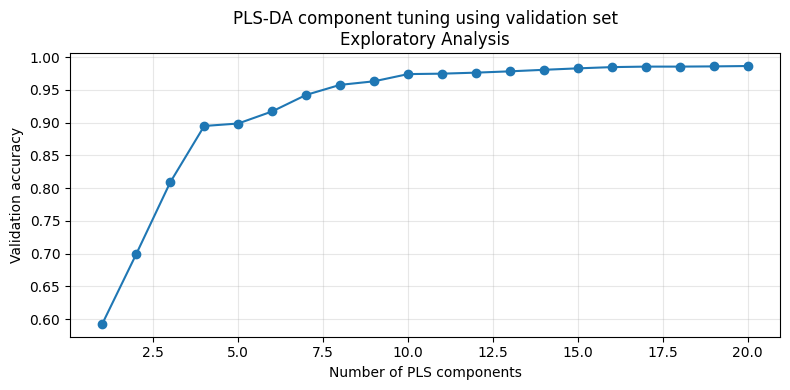

In [8]:
# --- Tune PLS-DA components using validation set ---
component_range = range(1, 21)
valid_scores = []

# Compute training-set mean only
train_mean = X_train.mean(axis=0)

# Apply same centering to train and validation
X_train_mc = X_train - train_mean
X_valid_mc = X_valid - train_mean

for n_comp in component_range:

    model = PLSRegression(n_components=n_comp, max_iter=500)

    model.fit(X_train_mc, Y_train)

    Y_valid_scores = model.predict(X_valid_mc)
    y_valid_pred = lb.classes_[np.argmax(Y_valid_scores, axis=1)]

    acc = accuracy_score(y_valid, y_valid_pred)
    valid_scores.append(acc)

best_n = component_range[np.argmax(valid_scores)]

print("Best number of PLS components:", best_n)
print("Best validation accuracy:", max(valid_scores))

plt.figure(figsize=(8, 4))
plt.plot(component_range, valid_scores, marker="o")
plt.xlabel("Number of PLS components")
plt.ylabel("Validation accuracy")
plt.title("PLS-DA component tuning using validation set\nExploratory Analysis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Number of PLS-DA components tuned using the validation set. 
* For each candidate number of components, the model is fitted only on the training set and evaluated on the validation set. The component number with the highest validation accuracy is selected, preventing the test set from influencing model selection and keeping the final test evaluation unbiased.

## 2. Final PLS-DA model - evaluation

In [9]:
# --- Compare PLS-DA using all bands vs PCA-selected bands ---
def evaluate_plsda_band_subset(
    X_train, Y_train, y_train,
    X_valid, Y_valid, y_valid,
    X_test, Y_test, y_test,
    band_indices,
    label
):
    """
    Train and evaluate multi-class PLS-DA using selected wavelength bands
    Mean centering is fitted on train set only and then applied to validation and test sets
    """

    X_train_sub = X_train[:, band_indices]
    X_valid_sub = X_valid[:, band_indices]
    X_test_sub  = X_test[:, band_indices]

    # Training-set mean only
    train_mean = X_train_sub.mean(axis=0)

    X_train_mc = X_train_sub - train_mean
    X_valid_mc = X_valid_sub - train_mean
    X_test_mc  = X_test_sub  - train_mean

    max_components = min(15, X_train_mc.shape[1], X_train_mc.shape[0] - 1)

    best_acc = -1
    best_n = None
    best_model = None

    for n_comp in range(1, max_components + 1):

        model = PLSRegression(
            n_components=n_comp,
            scale=False,
            max_iter=1000,
            tol=1e-6
        )
        
        model.fit(X_train_mc, Y_train)

        Y_valid_scores = model.predict(X_valid_mc)
        y_valid_pred = lb.classes_[np.argmax(Y_valid_scores, axis=1)]

        acc = accuracy_score(y_valid, y_valid_pred)

        if acc > best_acc:
            best_acc = acc
            best_n = n_comp
            best_model = model

    Y_test_scores = best_model.predict(X_test_mc)
    y_test_pred = lb.classes_[np.argmax(Y_test_scores, axis=1)]

    test_acc = accuracy_score(y_test, y_test_pred)

    return {
        "label": label,
        "n_bands": len(band_indices),
        "band_indices": band_indices,
        "wavelengths": wavelengths[band_indices],
        "best_n_components": best_n,
        "val_accuracy": best_acc,
        "test_accuracy": test_acc,
        "test_precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=lb.classes_),
        "y_test_pred": y_test_pred,
        "model": best_model,
        "train_mean": train_mean
    }

In [10]:
# --- PLS-DA comparison using usable, RGB and selected subsets ---

results_plsda_bands = []

# "All bands" now means the full usable 430–970 nm spectrum.
all_band_indices = usable_band_indices

band_cases = [
    ("PLS-DA: all bands", all_band_indices),

    ("PLS-DA: top 100 PCA bands", selected_band_indices_pca[:100]), 
    ("PLS-DA: top 100 VIP bands", selected_band_indices_vip[:100]),
    ("PLS-DA: top 80 PCA bands", selected_band_indices_pca[:80]), 
    ("PLS-DA: top 80 VIP bands", selected_band_indices_vip[:80]), 
    ("PLS-DA: top 50 PCA bands", selected_band_indices_pca[:50]), 
    ("PLS-DA: top 50 VIP bands", selected_band_indices_vip[:50]), 
    ("PLS-DA: top 30 PCA bands", selected_band_indices_pca[:30]), 
    ("PLS-DA: top 30 VIP bands", selected_band_indices_vip[:30]), 
    ("PLS-DA: top 20 PCA bands", selected_band_indices_pca[:20]), 
    ("PLS-DA: top 20 VIP bands", selected_band_indices_vip[:20]), 

    # The 1–10 band models use nested, peak-separated subsets
    ("PLS-DA: top 10 PCA bands", selected_10_band_indices_pca), 
    ("PLS-DA: top 10 VIP bands", selected_10_band_indices_vip), 
    ("PLS-DA: top 9 PCA bands", selected_9_band_indices_pca), 
    ("PLS-DA: top 9 VIP bands", selected_9_band_indices_vip), 
    ("PLS-DA: top 8 PCA bands", selected_8_band_indices_pca), 
    ("PLS-DA: top 8 VIP bands", selected_8_band_indices_vip),
    ("PLS-DA: top 7 PCA bands", selected_7_band_indices_pca), 
    ("PLS-DA: top 7 VIP bands", selected_7_band_indices_vip), 
    ("PLS-DA: top 6 PCA bands", selected_6_band_indices_pca), 
    ("PLS-DA: top 6 VIP bands", selected_6_band_indices_vip), 
    ("PLS-DA: top 5 PCA bands", selected_5_band_indices_pca), 
    ("PLS-DA: top 5 VIP bands", selected_5_band_indices_vip), 
    ("PLS-DA: top 4 PCA bands", selected_4_band_indices_pca), 
    ("PLS-DA: top 4 VIP bands", selected_4_band_indices_vip), 

    ("PLS-DA: RGB proxy bands", rgb_band_indices),
   
    ("PLS-DA: top 3 PCA bands", selected_3_band_indices_pca), 
    ("PLS-DA: top 3 VIP bands", selected_3_band_indices_vip), 
    ("PLS-DA: top 2 PCA bands", selected_2_band_indices_pca), 
    ("PLS-DA: top 2 VIP bands", selected_2_band_indices_vip), 
    ("PLS-DA: top 1 PCA band", selected_1_band_indices_pca), 
    ("PLS-DA: top 1 VIP band", selected_1_band_indices_vip),
]

for label, band_indices in band_cases:

    result = evaluate_plsda_band_subset(
        X_train, Y_train, y_train,
        X_valid, Y_valid, y_valid,
        X_test, Y_test, y_test,
        band_indices,
        label=label
    )

    results_plsda_bands.append(result)

    print(f"\n--- {label} ---")
    print(f"Number of bands: {result['n_bands']}")

    if result["n_bands"] <= 10:
        print(
            "Wavelengths:",
            np.round(wavelengths[band_indices], 1)
        )


    print(f"Best PLS components: " f"{result['best_n_components']}") 
    print(f"Validation accuracy: " f"{result['val_accuracy']:.4f}") 
    print(f"Test accuracy: " f"{result['test_accuracy']:.4f}")


--- PLS-DA: all bands ---
Number of bands: 199
Best PLS components: 15
Validation accuracy: 0.9867
Test accuracy: 0.9886

--- PLS-DA: top 100 PCA bands ---
Number of bands: 100
Best PLS components: 11
Validation accuracy: 0.9637
Test accuracy: 0.9706

--- PLS-DA: top 100 VIP bands ---
Number of bands: 100
Best PLS components: 15
Validation accuracy: 0.9710
Test accuracy: 0.9730

--- PLS-DA: top 80 PCA bands ---
Number of bands: 80
Best PLS components: 15
Validation accuracy: 0.9554
Test accuracy: 0.9613

--- PLS-DA: top 80 VIP bands ---
Number of bands: 80
Best PLS components: 10
Validation accuracy: 0.9617
Test accuracy: 0.9647

--- PLS-DA: top 50 PCA bands ---
Number of bands: 50
Best PLS components: 12
Validation accuracy: 0.9379
Test accuracy: 0.9434

--- PLS-DA: top 50 VIP bands ---
Number of bands: 50
Best PLS components: 10
Validation accuracy: 0.9179
Test accuracy: 0.9192

--- PLS-DA: top 30 PCA bands ---
Number of bands: 30
Best PLS components: 14
Validation accuracy: 0.8384


In [11]:
# --- Main result table: full spectra + thesis-relevant 1/3-band models ---

main_result_labels = [
    "PLS-DA: all bands",
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]

main_rows = []

for label in main_result_labels:
    r = next(res for res in results_plsda_bands if res["label"] == label)

    main_rows.append({
        "Model": label,
        "Bands": r["n_bands"],
        "Selected wavelengths [nm]": np.round(wavelengths[r["band_indices"]], 1).tolist(),
        "Best components": r["best_n_components"],
        "Validation accuracy": r["val_accuracy"],
        "Test accuracy": r["test_accuracy"],
    })

main_results_df = pd.DataFrame(main_rows)

display(main_results_df)


,Model,Bands,Selected wavelengths [nm],Best components,Validation accuracy,Test accuracy
0,PLS-DA: all bands,199,"[432.0, 434.6, 437.2, 439.8, 442.4, 445.0, 447...",15,0.986667,0.988556
1,PLS-DA: top 1 PCA band,1,[491.9],1,0.522000,0.522000
2,PLS-DA: top 1 VIP band,1,[497.2],1,0.527556,0.525222
3,PLS-DA: top 3 PCA bands,3,"[491.9, 611.9, 641.6]",3,0.813778,0.791778
4,PLS-DA: top 3 VIP bands,3,"[497.2, 609.2, 641.6]",3,0.819889,0.797667


,Model,Method,Number of bands,Best PLS components,Validation accuracy,Test accuracy
0,PLS-DA: all bands,All bands,199,15,0.986667,0.988556
1,PLS-DA: top 1 PCA band,PCA,1,1,0.522000,0.522000
2,PLS-DA: top 2 PCA bands,PCA,2,2,0.805000,0.782444
3,PLS-DA: top 3 PCA bands,PCA,3,3,0.813778,0.791778
4,PLS-DA: top 4 PCA bands,PCA,4,4,0.815667,0.797000
5,PLS-DA: top 5 PCA bands,PCA,5,4,0.861333,0.862778
6,PLS-DA: top 6 PCA bands,PCA,6,6,0.862889,0.862444
7,PLS-DA: top 7 PCA bands,PCA,7,7,0.864333,0.864889
8,PLS-DA: top 8 PCA bands,PCA,8,8,0.907889,0.913333
9,PLS-DA: top 9 PCA bands,PCA,9,7,0.915667,0.919556


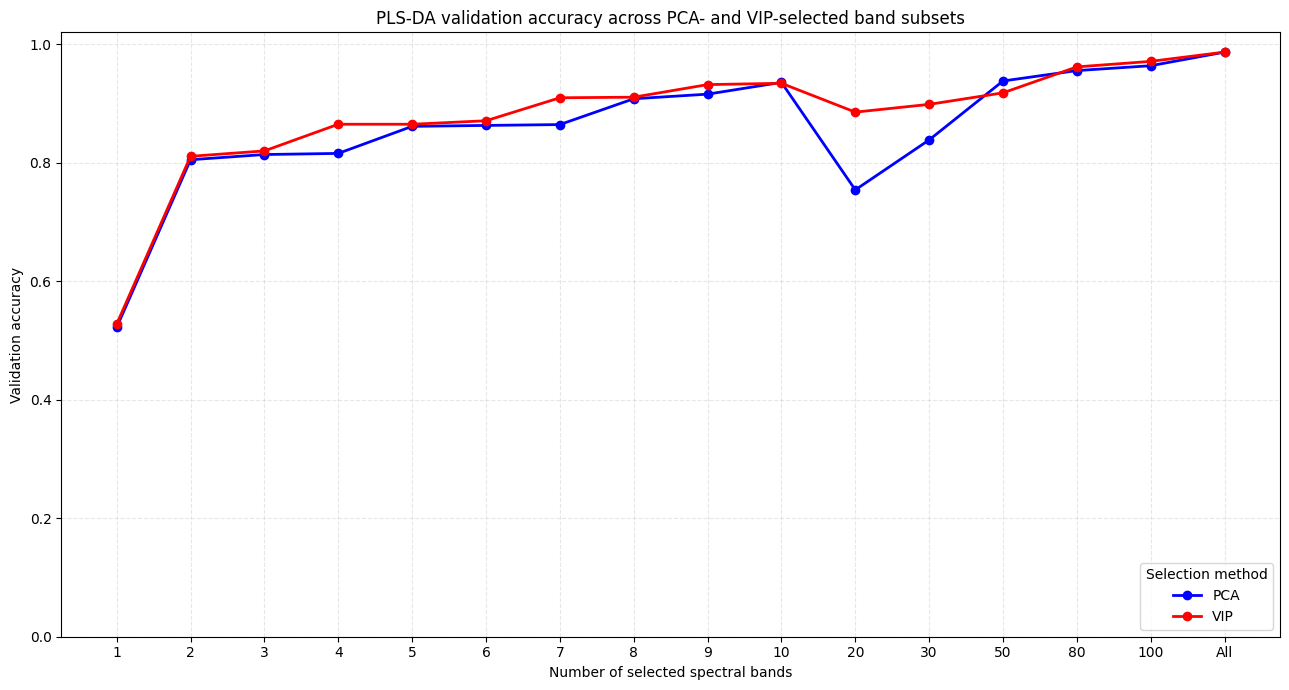

In [12]:
# --- Validation accuracy across PCA and VIP band subsets ---

# Build a clean metrics table
metrics_df = pd.DataFrame([
    {
        "Model": r["label"],
        "Method": (
            "VIP" if "VIP" in r["label"]
            else "PCA" if "PCA" in r["label"]
            else "RGB" if "RGB" in r["label"]
            else "All bands"
        ),
        "Number of bands": int(r["n_bands"]),
        "Best PLS components": int(r["best_n_components"]),
        "Validation accuracy": r["val_accuracy"],
        "Test accuracy": r["test_accuracy"]
    }
    for r in results_plsda_bands
])


# Retrieve the shared full-spectrum result
all_bands_rows = metrics_df[
    metrics_df["Method"] == "All bands"
].copy()

if all_bands_rows.empty:
    raise ValueError(
        "No full-spectrum result was found in results_plsda_bands."
    )

all_bands_row = all_bands_rows.iloc[0]
n_all_bands = int(all_bands_row["Number of bands"])


# Prepare one ordered dataframe for each selection method
method_dfs = {}

for method in ["PCA", "VIP"]:

    method_df = metrics_df[
        metrics_df["Method"] == method
    ].copy()

    # Add the full-spectrum result to both plots
    full_spectrum_reference = all_bands_row.copy()
    full_spectrum_reference["Method"] = method
    full_spectrum_reference["Model"] = (
        f"PLS-DA: all bands ({method} reference)"
    )

    method_df = pd.concat(
        [
            method_df,
            full_spectrum_reference.to_frame().T
        ],
        ignore_index=True
    )

    numeric_columns = [
        "Number of bands",
        "Best PLS components",
        "Validation accuracy",
        "Test accuracy"
    ]

    method_df[numeric_columns] = method_df[
        numeric_columns
    ].apply(pd.to_numeric)

    method_df = (
        method_df
        .drop_duplicates(
            subset=["Number of bands"],
            keep="first"
        )
        .sort_values("Number of bands")
        .reset_index(drop=True)
    )

    method_dfs[method] = method_df


# Display the underlying results once
display(
    metrics_df.sort_values(
        ["Method", "Number of bands"]
    ).reset_index(drop=True)
)


# Shared x-axis ordering
band_order = (
    pd.concat([
        method_dfs["PCA"]["Number of bands"],
        method_dfs["VIP"]["Number of bands"]
    ])
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# Place the all-band case last
if n_all_bands in band_order:
    band_order.remove(n_all_bands)
    band_order.append(n_all_bands)

x_positions = np.arange(len(band_order))

x_labels = [
    "All"
    if int(n_bands) == n_all_bands
    else str(int(n_bands))
    for n_bands in band_order
]

method_colours = {
    "PCA": "blue",
    "VIP": "red"
}


# Plot validation accuracy
fig, ax = plt.subplots(figsize=(13, 7))

for method in ["PCA", "VIP"]:

    plot_df = (
        method_dfs[method]
        .set_index("Number of bands")
        .reindex(band_order)
    )

    ax.plot(
        x_positions,
        plot_df["Validation accuracy"],
        color=method_colours[method],
        linestyle="-",
        marker="o",
        linewidth=2,
        markersize=6,
        label=method
    )

ax.set_xticks(
    x_positions,
    x_labels
)

ax.set_xlabel("Number of selected spectral bands")
ax.set_ylabel("Validation accuracy")

ax.set_title(
    "PLS-DA validation accuracy across "
    "PCA- and VIP-selected band subsets"
)

ax.set_ylim(0, 1.02)

ax.grid(
    True,
    alpha=0.3,
    linestyle="--"
)

ax.legend(
    title="Selection method",
    loc="lower right"
)

plt.tight_layout()
plt.show()

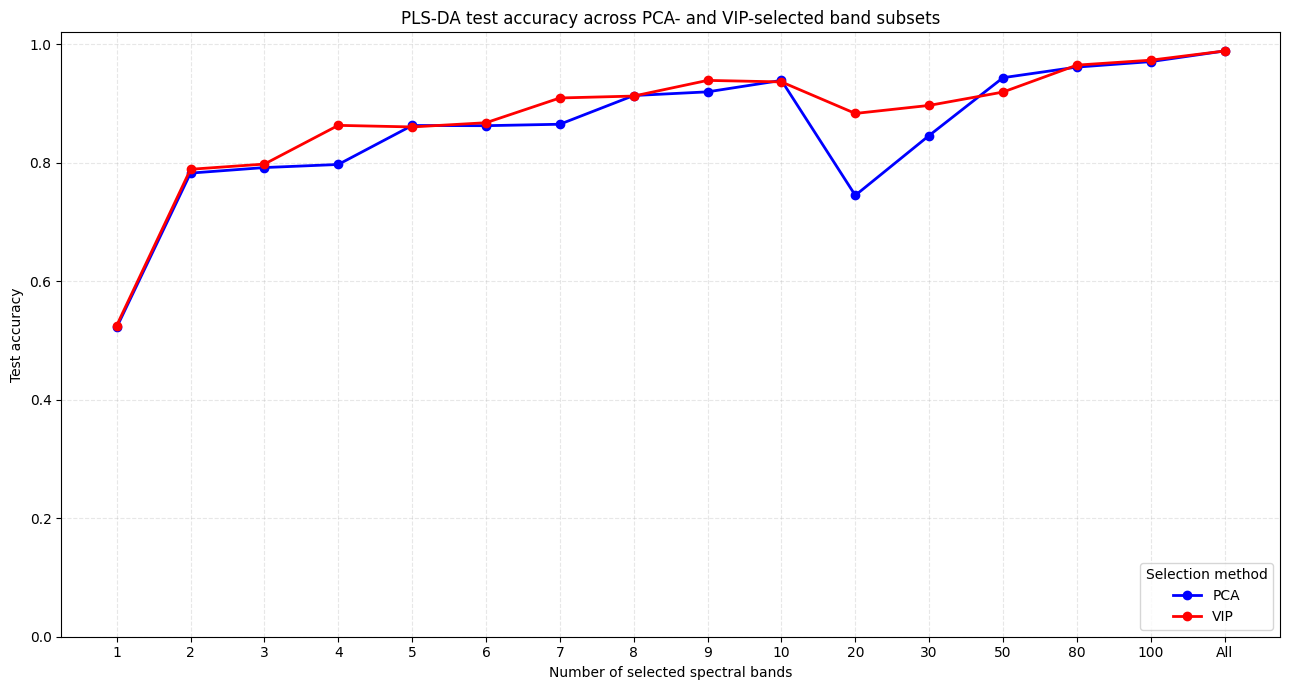

In [13]:
# --- Test accuracy across PCA and VIP band subsets ---

fig, ax = plt.subplots(figsize=(13, 7))

for method in ["PCA", "VIP"]:

    plot_df = (
        method_dfs[method]
        .set_index("Number of bands")
        .reindex(band_order)
    )

    ax.plot(
        x_positions,
        plot_df["Test accuracy"],
        color=method_colours[method],
        linestyle="-",
        marker="o",
        linewidth=2,
        markersize=6,
        label=method
    )

ax.set_xticks(
    x_positions,
    x_labels
)

ax.set_xlabel("Number of selected spectral bands")
ax.set_ylabel("Test accuracy")

ax.set_title(
    "PLS-DA test accuracy across "
    "PCA- and VIP-selected band subsets"
)

ax.set_ylim(0, 1.02)

ax.grid(
    True,
    alpha=0.3,
    linestyle="--"
)

ax.legend(
    title="Selection method",
    loc="lower right"
)

plt.tight_layout()
plt.show()

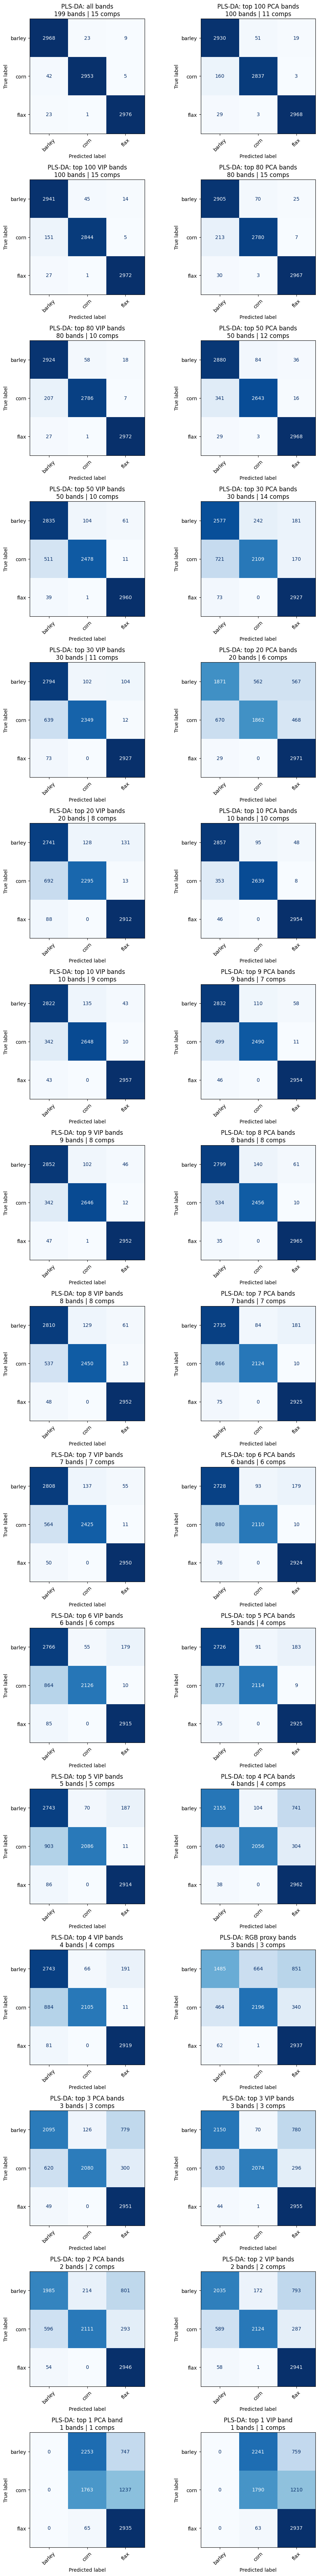

In [14]:
# --- Plot confusion matrices side by side ---
n_models = len(results_plsda_bands)
max_per_row = 2

n_rows = math.ceil(n_models / max_per_row)
n_cols = min(max_per_row, n_models)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows)
)

if n_rows == 1 and n_cols == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for ax, result in zip(axes, results_plsda_bands):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=lb.classes_
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"{result['label']}\n"
        f"{result['n_bands']} bands | {result['best_n_components']} comps"
    )

    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(results_plsda_bands):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

It seems that the best combination of retaining the least bands possible, whilst still obtaining reliable classification performance is going with the top 20 bands. This represents just a sixth of the full set, yet as the line graph and confusion matrices above show, still achieves respectable performance. Accuracy, precision, recall and F1 score all hover around 74%, whilst the correctly predicted cases still very much outweigh the other cases in the confusion matrix.

## Confusion Matrices seperared by volume 

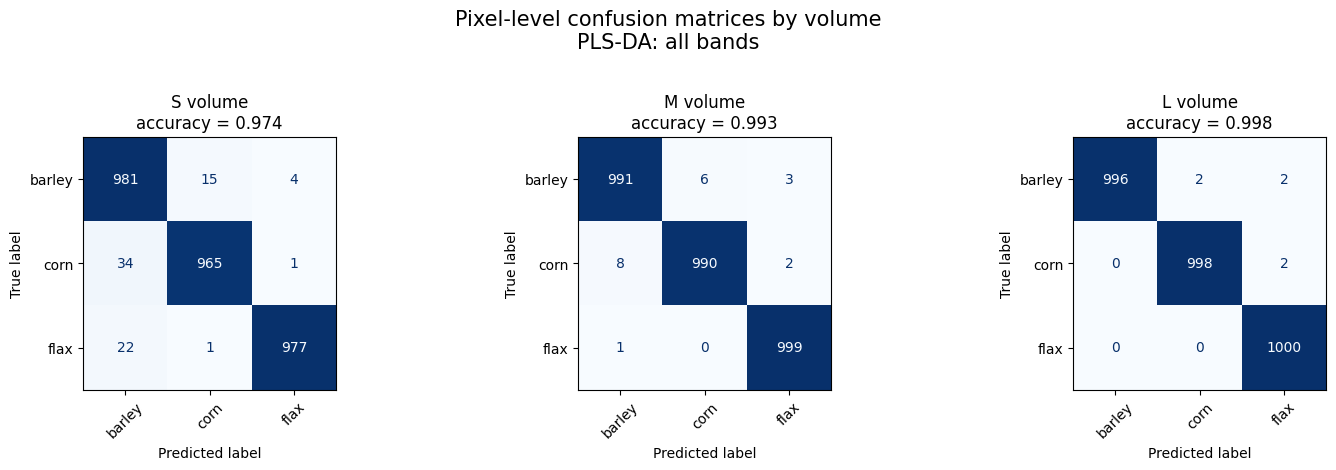

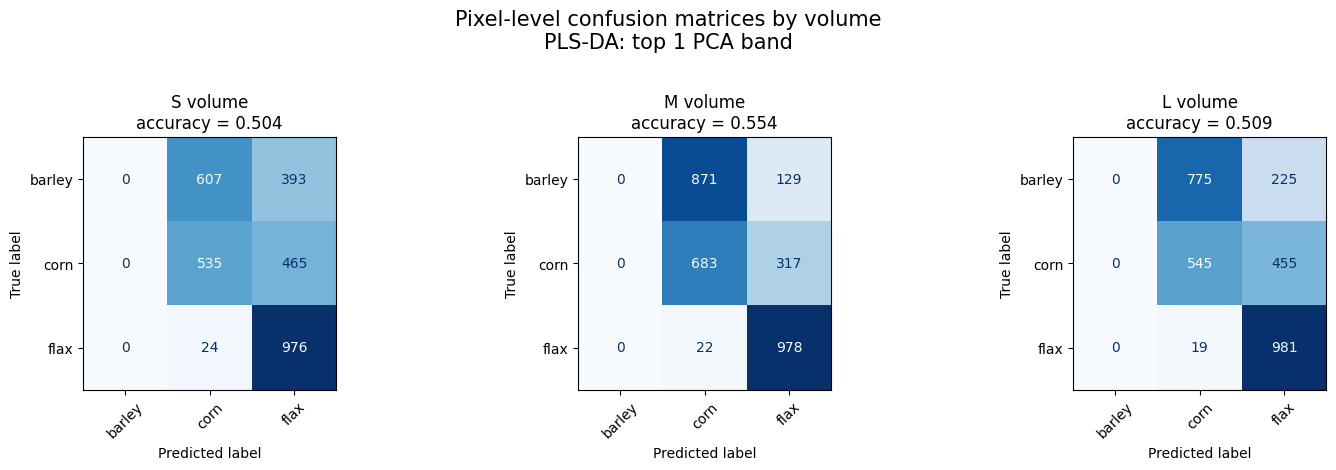

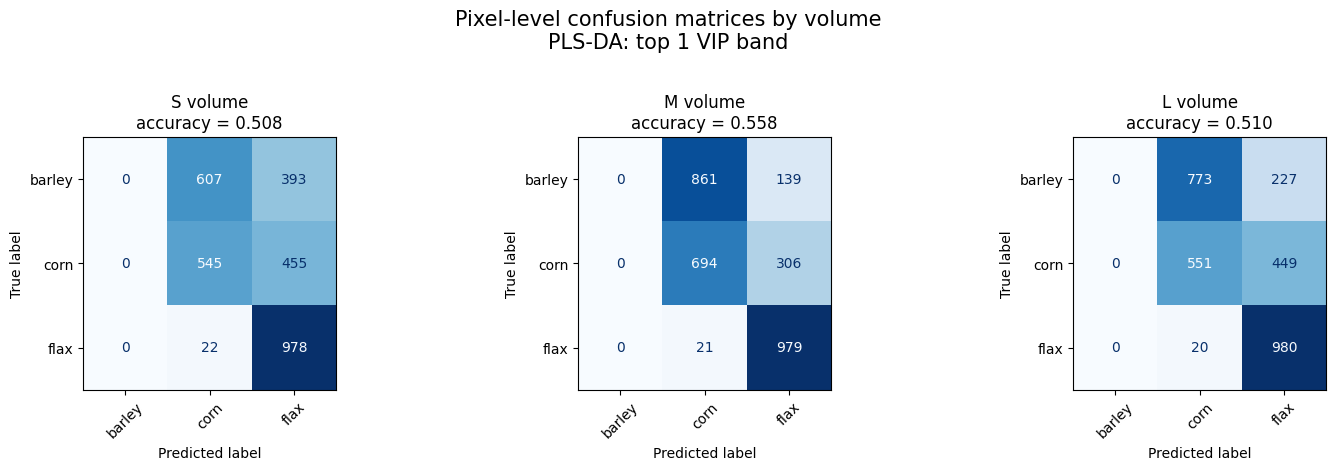

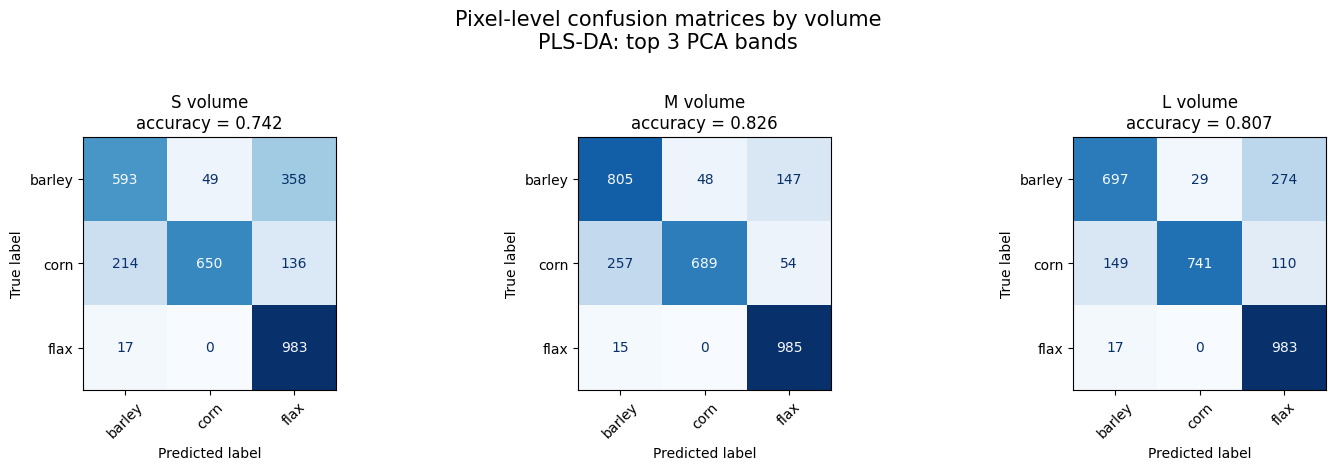

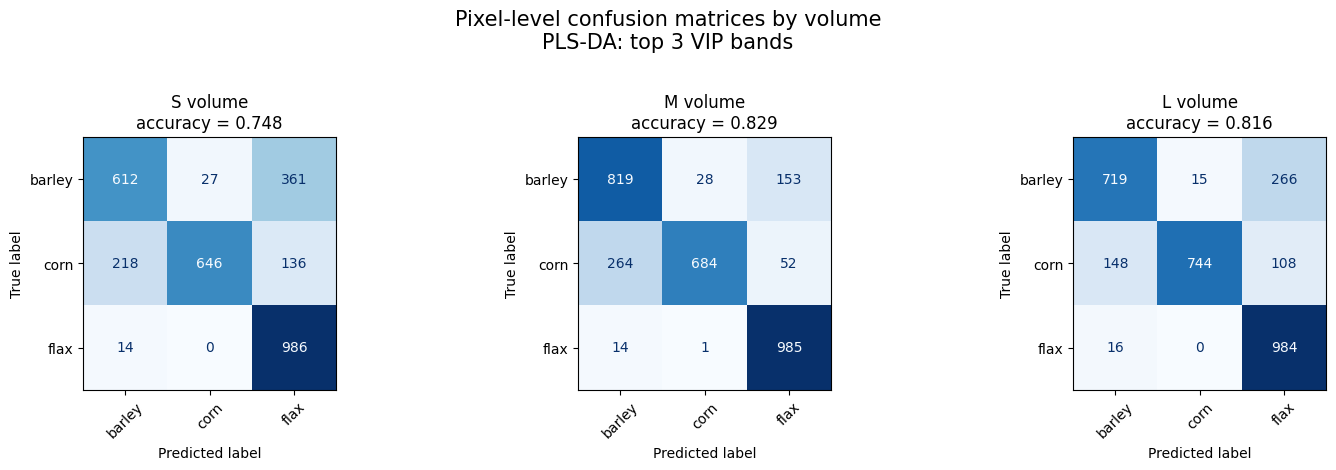

In [15]:
# --- Additional pixel-level confusion matrices for every volume ---

volume_order = [
    volume
    for volume in ["s", "m", "l"]
    if volume in np.unique(size_all)
]

# Use the main thesis-relevant models.
volume_cm_labels = [
    "PLS-DA: all bands",
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]

test_sizes = np.asarray(
    size_all[test_mask]
)

if len(test_sizes) != len(y_test):
    raise ValueError(
        "Test volume labels do not match y_test."
    )


volume_cm_summary_rows = []


for result_label in volume_cm_labels:

    result = next(
        result
        for result in results_plsda_bands
        if result["label"] == result_label
    )

    y_pred = np.asarray(
        result["y_test_pred"]
    )

    if len(y_pred) != len(y_test):
        raise ValueError(
            f"Prediction-length mismatch for {result_label}."
        )

    fig, axes = plt.subplots(
        1,
        len(volume_order),
        figsize=(5 * len(volume_order), 4.5)
    )

    axes = np.atleast_1d(
        axes
    ).ravel()


    for ax, volume in zip(
        axes,
        volume_order
    ):

        volume_mask = (
            test_sizes == volume
        )

        y_true_volume = y_test[
            volume_mask
        ]

        y_pred_volume = y_pred[
            volume_mask
        ]

        if len(y_true_volume) == 0:
            ax.axis("off")
            continue

        cm = confusion_matrix(
            y_true_volume,
            y_pred_volume,
            labels=lb.classes_
        )

        volume_accuracy = accuracy_score(
            y_true_volume,
            y_pred_volume
        )

        volume_balanced_accuracy = (
            balanced_accuracy_score(
                y_true_volume,
                y_pred_volume
            )
        )

        volume_f1 = f1_score(
            y_true_volume,
            y_pred_volume,
            labels=lb.classes_,
            average="macro",
            zero_division=0
        )

        volume_cm_summary_rows.append({
            "Model": result_label,
            "Volume": volume,
            "Number of test pixels": len(
                y_true_volume
            ),
            "Accuracy": volume_accuracy,
            "Balanced accuracy": (
                volume_balanced_accuracy
            ),
            "Macro F1": volume_f1
        })

        display_cm = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=lb.classes_
        )

        display_cm.plot(
            ax=ax,
            cmap="Blues",
            values_format="d",
            colorbar=False
        )

        ax.set_title(
            f"{volume.capitalize()} volume\n"
            f"accuracy = {volume_accuracy:.3f}"
        )

        ax.tick_params(
            axis="x",
            rotation=45
        )


    fig.suptitle(
        f"Pixel-level confusion matrices by volume\n"
        f"{result_label}",
        fontsize=15,
        y=1.03
    )

    plt.tight_layout()
    plt.show()


## Image-level majority vote Confusion Matrices

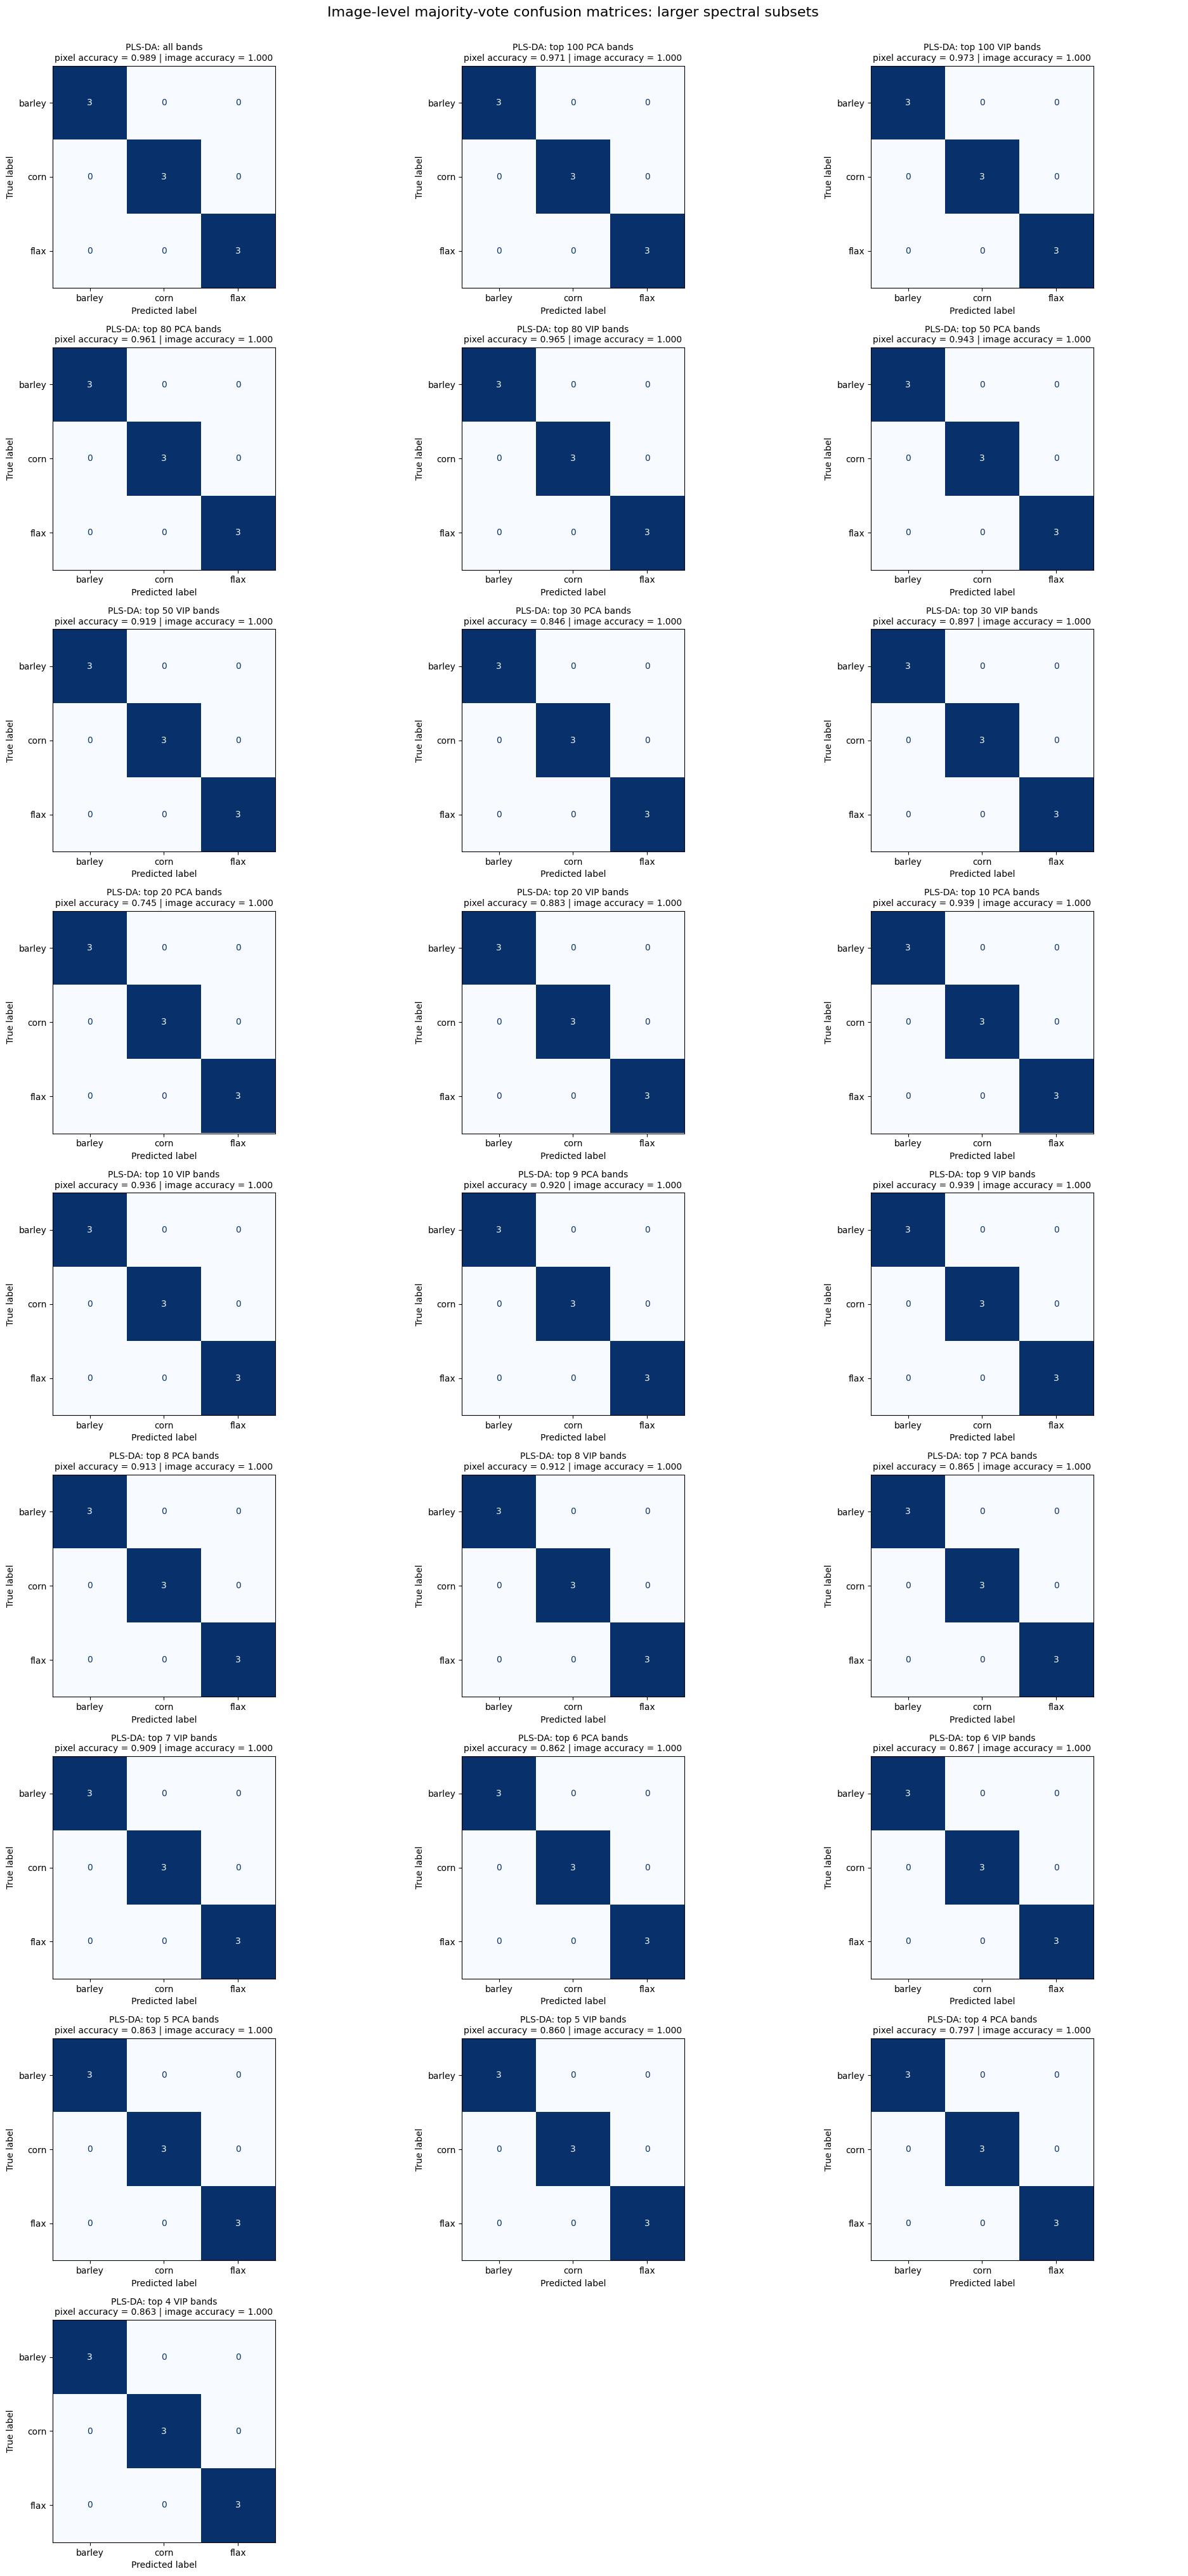

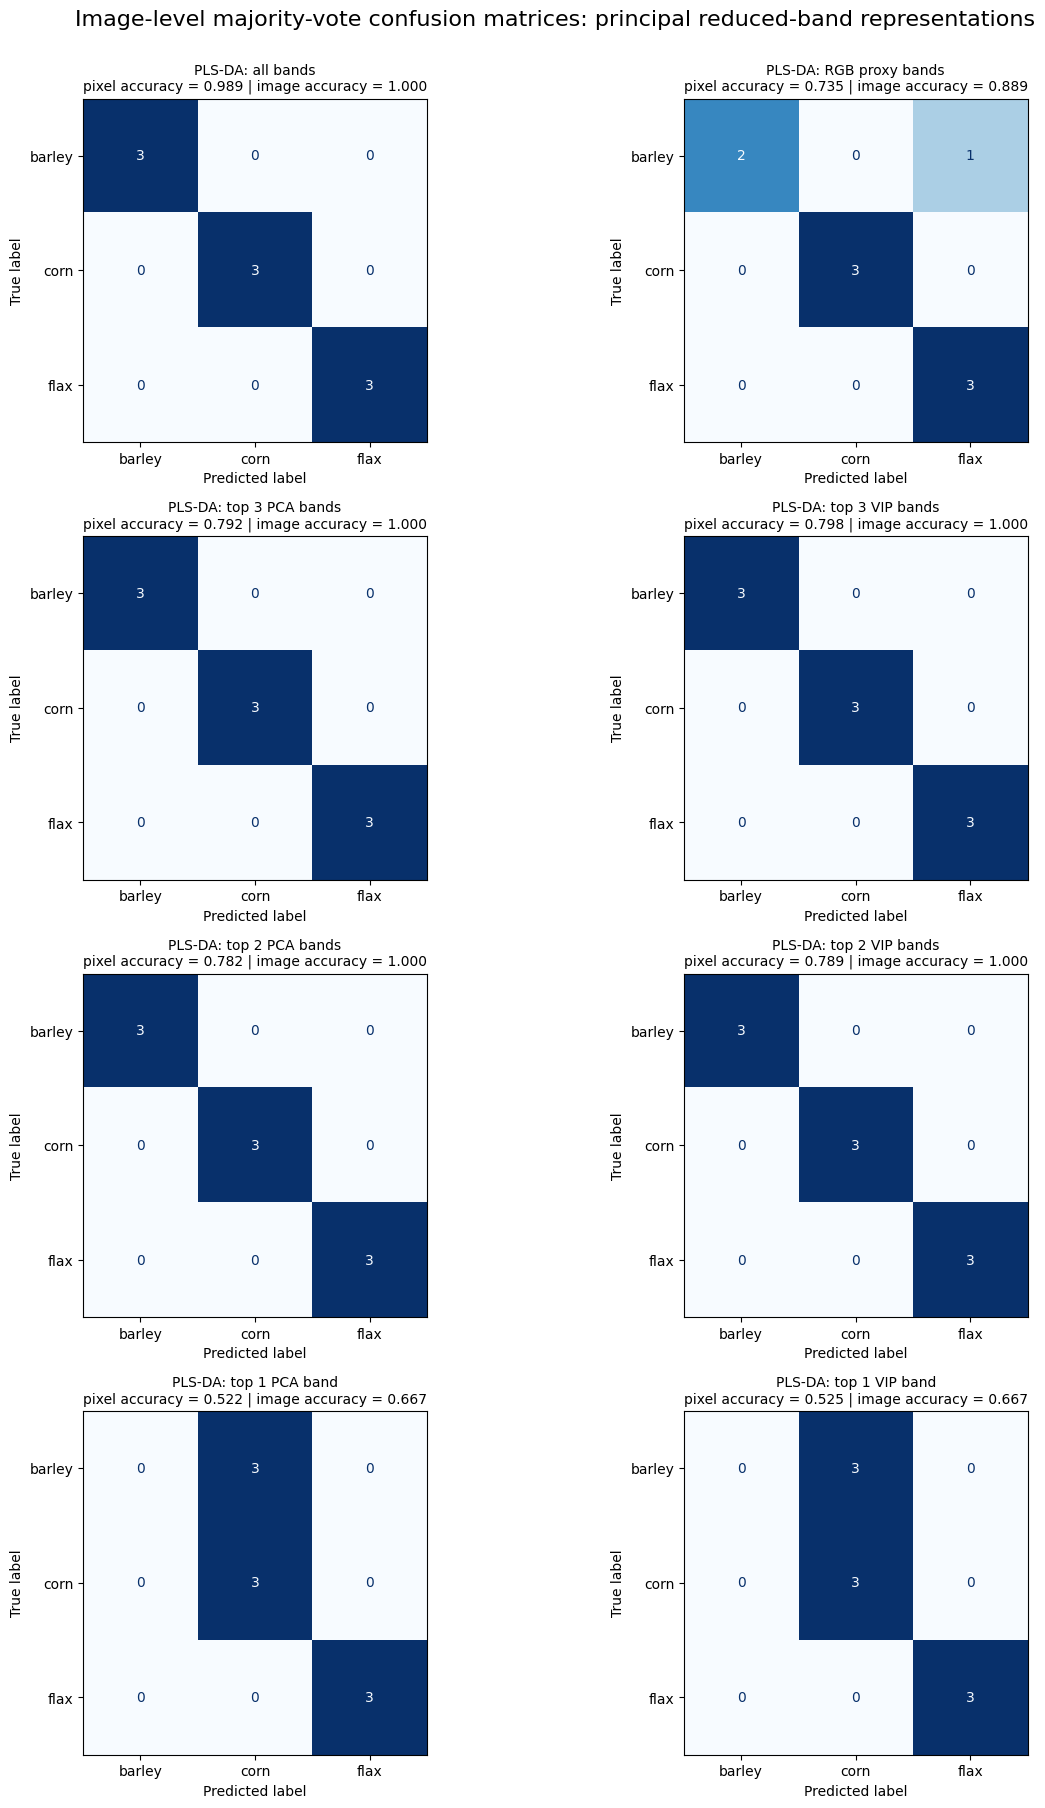

In [16]:
# These retain the same ordering as X_test, y_test and each result["y_test_pred"] array
test_image_ids = np.asarray(
    image_id_all[test_mask]
)

test_sizes = np.asarray(
    size_all[test_mask]
)


# Basic consistency checks
if len(test_image_ids) != len(y_test): raise ValueError( "test_image_ids and y_test have different lengths." )
if len(test_sizes) != len(y_test): raise ValueError( "test_sizes and y_test have different lengths." )

image_level_rows = []

# Convert each model's pixel predictions into image predictions
for result in results_plsda_bands:

    result_label = result["label"]

    y_pred_pixels = np.asarray(result["y_test_pred"])

    if len(y_pred_pixels) != len(y_test): raise ValueError( f"Prediction length mismatch for {result_label}." )

    y_true_images = []
    y_pred_images = []

    # Preserve the image order occurring in the test set.
    unique_test_images = pd.unique(
        test_image_ids
    )

    for image_id in unique_test_images:
        image_mask = ( test_image_ids == image_id )

        image_true_labels = np.unique( y_test[image_mask] )

        image_sizes = np.unique( test_sizes[image_mask] )

        if len(image_true_labels) != 1: raise ValueError( f"Image {image_id} contains multiple true labels." )
        if len(image_sizes) != 1: raise ValueError( f"Image {image_id} contains multiple size labels." )

        true_label = image_true_labels[0]
        image_size = image_sizes[0]

        image_pixel_predictions = (
            y_pred_pixels[image_mask]
        )

        # Count the number of pixel votes for each class.
        vote_counts = np.array([
            np.sum( image_pixel_predictions == class_label )
            for class_label in lb.classes_
        ])

        maximum_votes = vote_counts.max()
        tied_class_indices = np.flatnonzero( vote_counts == maximum_votes )

        vote_tie = ( len(tied_class_indices) > 1 )

        if not vote_tie:

            winning_class_index = int( tied_class_indices[0] )

        else:
            # A tie is unlikely, but resolve it using the mean
            # PLS score among only the tied classes.
            band_indices = result[ "band_indices" ]

            X_image = X_test[
                image_mask
            ][
                :, band_indices
            ]

            X_image_mc = (
                X_image
                - result["train_mean"]
            )

            mean_image_scores = (
                result["model"]
                .predict(X_image_mc)
                .mean(axis=0)
            )

            winning_class_index = int(
                tied_class_indices[
                    np.argmax(
                        mean_image_scores[
                            tied_class_indices
                        ]
                    )
                ]
            )

        majority_prediction = (
            lb.classes_[
                winning_class_index
            ]
        )

        pixel_accuracy_within_image = (
            image_pixel_predictions
            == true_label
        ).mean()

        y_true_images.append(
            true_label
        )

        y_pred_images.append(
            majority_prediction
        )

        image_row = {
            "Model": result_label,
            "Number of bands": result["n_bands"],
            "Image ID": image_id,
            "Size": image_size,
            "True label": true_label,
            "Majority prediction": majority_prediction,
            "Image correct": (
                majority_prediction
                == true_label
            ),
            "Pixel accuracy within image": (
                pixel_accuracy_within_image
            ),
            "Number of sampled pixels": int(
                image_mask.sum()
            ),
            "Vote tie": vote_tie
        }

        # Save each class's vote count and percentage.
        for class_index, class_label in enumerate(
            lb.classes_
        ):

            image_row[
                f"{class_label} votes"
            ] = int(
                vote_counts[class_index]
            )

            image_row[
                f"{class_label} vote proportion"
            ] = (
                vote_counts[class_index]
                / image_mask.sum()
            )

        image_level_rows.append(
            image_row
        )


    y_true_images = np.asarray( y_true_images )

    y_pred_images = np.asarray( y_pred_images )

    image_cm = confusion_matrix(
        y_true_images,
        y_pred_images,
        labels=lb.classes_
    )

    # Add the image-level results to the existing result dictionary.
    result["image_accuracy"] = accuracy_score(
        y_true_images,
        y_pred_images
    )

    result[
        "image_balanced_accuracy"
    ] = balanced_accuracy_score(
        y_true_images,
        y_pred_images
    )

    result[
        "image_f1_macro"
    ] = f1_score(
        y_true_images,
        y_pred_images,
        average="macro",
        zero_division=0
    )

    result[ "image_confusion_matrix" ] = image_cm
    result[ "y_test_image" ] = y_true_images
    result[ "y_pred_image" ] = y_pred_images


# Per-image results
image_level_df = pd.DataFrame( image_level_rows )


# --- Image-level confusion matrices in two explicitly defined figures ---

def is_full_spectrum(result):
    label = str(result["label"]).lower()

    return (
        "all bands" in label
        or "full spectrum" in label
    )


def is_rgb(result):
    label = str(result["label"]).lower()

    return "rgb" in label


def is_selected_small_subset(result):
    label = str(result["label"]).lower()

    return (
        result["n_bands"] in [1, 2, 3]
        and (
            "pca" in label
            or "vip" in label
        )
    )


main_results = [
    result
    for result in results_plsda_bands
    if (
        is_full_spectrum(result)
        or (
            not is_rgb(result)
            and not is_selected_small_subset(result)
        )
    )
]

small_subset_results = [
    result
    for result in results_plsda_bands
    if (
        is_full_spectrum(result)
        or is_rgb(result)
        or is_selected_small_subset(result)
    )
]


# Explicit ordering for Figure 1
def main_sort_key(result):

    if is_full_spectrum(result):
        return (0, 0, 0)

    label = str(
        result["label"]
    ).lower()

    n_bands = int(
        result["n_bands"]
    )

    # Larger subsets first
    if "pca" in label:
        method_order = 0

    elif "vip" in label:
        method_order = 1

    else:
        method_order = 2

    return (
        1,
        -n_bands,
        method_order
    )


main_results = sorted(
    main_results,
    key=main_sort_key
)


# Explicit ordering for Figure 2
def small_subset_sort_key(result):

    if is_full_spectrum(result):
        return (0, 0)

    if is_rgb(result):
        return (0, 1)

    label = str(
        result["label"]
    ).lower()

    n_bands = int(
        result["n_bands"]
    )

    # 3-band before 2-band before 1-band
    band_order = {
        3: 1,
        2: 2,
        1: 3
    }[n_bands]

    # PCA left, VIP right
    if "pca" in label:
        method_order = 0
    else:
        method_order = 1

    return (
        band_order,
        method_order
    )


small_subset_results = sorted(
    small_subset_results,
    key=small_subset_sort_key
)


# Reusable plotting function
def plot_image_confusion_matrices(
    results_to_plot,
    figure_title,
    n_columns
):

    n_models = len(
        results_to_plot
    )

    n_rows = int(
        np.ceil(
            n_models
            / n_columns
        )
    )

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(
            6.5 * n_columns,
            4.5 * n_rows
        )
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, result in zip(
        axes,
        results_to_plot
    ):

        display_cm = ConfusionMatrixDisplay(
            confusion_matrix=result[
                "image_confusion_matrix"
            ],
            display_labels=lb.classes_
        )

        display_cm.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format="d"
        )

        ax.set_title(
            f"{result['label']}\n"
            f"pixel accuracy = "
            f"{result['test_accuracy']:.3f} | "
            f"image accuracy = "
            f"{result['image_accuracy']:.3f}",
            fontsize=10
        )

    # Hide unused subplot positions.
    for ax in axes[
        n_models:
    ]:
        ax.axis("off")

    fig.suptitle(
        figure_title,
        fontsize=16,
        y=1.002
    )

    plt.tight_layout()
    plt.show()


# Figure 1: Full spectrum + all larger PCA/VIP subsets

plot_image_confusion_matrices(
    main_results,
    (
        "Image-level majority-vote confusion matrices: "
        "larger spectral subsets"
    ),
    n_columns=3
)

# Figure 2: Full spectrum + RGB + PCA/VIP 1-, 2-, and 3-band subsets

plot_image_confusion_matrices(
    small_subset_results,
    (
        "Image-level majority-vote confusion matrices: "
        "principal reduced-band representations"
    ),
    n_columns=2
)

## Visualizing Results as overplay plots

In [18]:
# --- Incorrect/correct pixel overlay + Classes overlay ---
labels_to_plot = [
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]

class_colours = {
    "barley": [0.121, 0.466, 0.705, 0.45],
    "corn":   [1.000, 0.498, 0.054, 0.45],
    "flax":   [0.172, 0.627, 0.172, 0.45],
}

correct_colour = [0, 1, 0, 0.35]
wrong_colour   = [1, 0, 0, 0.35]


def normalise_for_display(img, mask):
    vals = img[mask]
    lo, hi = np.percentile(vals, [2, 98])
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)


def make_overlay_filename(result_label, class_label):
    label = result_label.lower()
    n_bands = re.search(r"top\s*(\d+)", label).group(1)

    if "pca" in label:
        method = "pca"
    elif "vip" in label:
        method = "vip"
    else:
        method = "unknown"

    return f"top{n_bands}_{method}_{class_label}.png"


test_image_rows = files_split[files_split["split"] == "test"].copy()
test_image_rows = test_image_rows.sort_values(["variety", "size", "rep"]).reset_index(drop=True)

for result_label in labels_to_plot:

    result_to_plot = next(
        r for r in results_plsda_bands
        if r["label"] == result_label
    )

    model = result_to_plot["model"]
    band_indices = result_to_plot["band_indices"]
    train_mean = result_to_plot["train_mean"]

    print("\n" + "=" * 90)
    print("Visualising:", result_label)
    print("Bands:", len(band_indices))
    print("Wavelengths:", np.round(wavelengths[band_indices], 1))

    for class_label in ["barley", "corn", "flax"]:

        class_rows = test_image_rows[test_image_rows["variety"] == class_label].reset_index(drop=True)

        fig, axes = plt.subplots(
            len(class_rows),
            2,
            figsize=(20, 40)
        )

        if len(class_rows) == 1:
            axes = np.array([axes])

        for row_idx, row in class_rows.iterrows():

            ax_correct = axes[row_idx, 0]
            ax_class = axes[row_idx, 1]

            sample_name = row["sample_name"]
            true_label = row["variety"]
            size = row["size"]
            filepath = row["filepath_FX10"]

            hcube, wlens_img, darkref, whiteref = load_cube(filepath)
            hcube_c = hcube[75:1025, 100:875, :]

            mask = build_foreground_mask_auto(
                hcube_c,
                size=size,
                true_label=true_label
            )

            mask_binary = mask > 0
            y_coords, x_coords = np.nonzero(mask_binary)

            X_img = hcube_c[y_coords, x_coords, :]
            X_img_sub = X_img[:, band_indices]
            X_img_mc = X_img_sub - train_mean

            Y_scores = model.predict(X_img_mc)
            y_pred_pixels = lb.classes_[np.argmax(Y_scores, axis=1)]

            correct_pixels = y_pred_pixels == true_label
            pixel_acc = correct_pixels.mean()
            majority_pred = Counter(y_pred_pixels).most_common(1)[0][0]

            base_img = hcube_c.mean(axis=2)
            base_img_norm = normalise_for_display(base_img, mask_binary)

            overlay_correct = np.zeros((*base_img.shape, 4), dtype=float)
            overlay_correct[y_coords[correct_pixels], x_coords[correct_pixels], :] = correct_colour
            overlay_correct[y_coords[~correct_pixels], x_coords[~correct_pixels], :] = wrong_colour

            overlay_class = np.zeros((*base_img.shape, 4), dtype=float)
            for cls, colour in class_colours.items():
                cls_pixels = y_pred_pixels == cls
                overlay_class[y_coords[cls_pixels], x_coords[cls_pixels], :] = colour

            title = (
                f"{sample_name}\n"
                f"T: {true_label} | M: {majority_pred} | Acc: {pixel_acc:.3f}"
            )

            ax_correct.imshow(base_img_norm, cmap="gray")
            ax_correct.imshow(overlay_correct)
            ax_correct.set_title(title + "\nCorrect / incorrect", fontsize=20, pad=3)
            ax_correct.set_aspect("equal")
            ax_correct.axis("off")

            ax_class.imshow(base_img_norm, cmap="gray")
            ax_class.imshow(overlay_class)
            ax_class.set_title(title + "\nPredicted class", fontsize=20, pad=3)
            ax_class.set_aspect("equal")
            ax_class.axis("off")

        legend_handles = [
            mpatches.Patch(color=correct_colour, label="Correct pixels"),
            mpatches.Patch(color=wrong_colour, label="Incorrect pixels"),
            mpatches.Patch(color=class_colours["barley"], label="Predicted barley"),
            mpatches.Patch(color=class_colours["corn"], label="Predicted corn"),
            mpatches.Patch(color=class_colours["flax"], label="Predicted flax"),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.015),
            ncol=5,
            fontsize=20
        )

        fig.suptitle(
            f"{result_label} | true class: {class_label} | "
            f"wavelengths: {np.round(wavelengths[band_indices], 1)} nm",
            fontsize=30,
            y=0.985
        )

        fig.subplots_adjust(
            left=0.03,
            right=0.97,
            top=0.94,
            bottom=0.06,
            hspace=0.18,
            wspace=0.02
        )

        filename = make_overlay_filename(result_label, class_label)
        save_path = os.path.join(os.getcwd(), filename)

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close(fig)

        print(f'Saved "{result_label}" / "{class_label}" as image "{save_path}"')


Visualising: PLS-DA: top 1 PCA band
Bands: 1
Wavelengths: [491.9]
Saved "PLS-DA: top 1 PCA band" / "barley" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_pca_barley.png"
Saved "PLS-DA: top 1 PCA band" / "corn" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_pca_corn.png"
Saved "PLS-DA: top 1 PCA band" / "flax" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_pca_flax.png"

Visualising: PLS-DA: top 1 VIP band
Bands: 1
Wavelengths: [497.2]
Saved "PLS-DA: top 1 VIP band" / "barley" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_vip_barley.png"
Saved "PLS-DA: top 1 VIP band" / "corn" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_vip_corn.png"
Saved "PLS-DA: top 1 VIP band" / "flax" as image "/home/isaacmuscat/Grain-Variety-Classification/top1_vip_flax.png"

Visualising: PLS-DA: top 3 PCA bands
Bands: 3
Wavelengths: [491.9 611.9 641.6]
Saved "PLS-DA: top 3 PCA bands" / "barley" as image "/home/isaacmuscat/Grain-Varie

In [19]:
# --- Error enrichment by spatial and radiometric characteristics ---
diagnostic_model_labels = [
    "PLS-DA: top 1 PCA band",
    "PLS-DA: top 1 VIP band",
    "PLS-DA: top 3 PCA bands",
    "PLS-DA: top 3 VIP bands",
]


BOUNDARY_DISTANCE_PIXELS = 3

DARK_QUANTILE = 0.20
BRIGHT_QUANTILE = 0.80
HIGH_GRADIENT_QUANTILE = 0.80

PREDICTION_CHUNK_SIZE = 100000


test_image_rows = (
    files_split[
        files_split["split"] == "test"
    ]
    .copy()
    .sort_values(
        ["variety", "size", "rep"]
    )
    .reset_index(drop=True)
)


spatial_characteristic_rows = []


for result_label in diagnostic_model_labels:

    result = next(
        result
        for result in results_plsda_bands
        if result["label"] == result_label
    )

    model = result["model"]

    band_indices = np.asarray(
        result["band_indices"],
        dtype=int
    )

    train_mean = np.asarray(
        result["train_mean"]
    )


    for _, row in test_image_rows.iterrows():

        sample_name = row["sample_name"]
        true_label = row["variety"]
        size = row["size"]
        filepath = row["filepath_FX10"]


        hcube, current_wavelengths, darkref, whiteref = (
            load_cube(
                filepath
            )
        )

        hcube_c = hcube[
            75:1025,
            100:875,
            :
        ]


        foreground_mask = (
            build_foreground_mask_auto(
                hcube_c,
                size=size,
                true_label=true_label
            )
            > 0
        )


        y_coords, x_coords = np.nonzero(
            foreground_mask
        )


        # Mean image used only for spatial/radiometric
        # characterisation, not for classification.
        mean_image = hcube_c.mean(
            axis=2
        )


        foreground_intensity = mean_image[
            foreground_mask
        ]


        intensity_low = np.quantile(
            foreground_intensity,
            DARK_QUANTILE
        )

        intensity_high = np.quantile(
            foreground_intensity,
            BRIGHT_QUANTILE
        )


        dark_mask = (
            foreground_mask
            & (
                mean_image
                <= intensity_low
            )
        )

        bright_mask = (
            foreground_mask
            & (
                mean_image
                >= intensity_high
            )
        )


        # Local gradients capture abrupt transitions,
        # including many individual-kernel margins.
        gradient_y = sobel(
            mean_image,
            axis=0
        )

        gradient_x = sobel(
            mean_image,
            axis=1
        )

        gradient_magnitude = np.sqrt(
            gradient_x ** 2
            + gradient_y ** 2
        )


        gradient_threshold = np.quantile(
            gradient_magnitude[
                foreground_mask
            ],
            HIGH_GRADIENT_QUANTILE
        )


        high_gradient_mask = (
            foreground_mask
            & (
                gradient_magnitude
                >= gradient_threshold
            )
        )


        distance_to_background = (
            distance_transform_edt(
                foreground_mask
            )
        )


        outer_boundary_mask = (
            foreground_mask
            & (
                distance_to_background
                <= BOUNDARY_DISTANCE_PIXELS
            )
        )


        low_gradient_interior_mask = (
            foreground_mask
            & ~high_gradient_mask
            & ~outer_boundary_mask
        )


        # Predict in chunks to avoid constructing one very
        # large selected-band matrix.
        predicted_labels = np.empty(
            len(y_coords),
            dtype=object
        )


        for chunk_start in range(
            0,
            len(y_coords),
            PREDICTION_CHUNK_SIZE
        ):

            chunk_stop = min(
                chunk_start
                + PREDICTION_CHUNK_SIZE,
                len(y_coords)
            )

            chunk_y = y_coords[
                chunk_start:chunk_stop
            ]

            chunk_x = x_coords[
                chunk_start:chunk_stop
            ]


            X_chunk = np.column_stack([
                hcube_c[
                    chunk_y,
                    chunk_x,
                    band_index
                ]
                for band_index in band_indices
            ])


            X_chunk_mc = (
                X_chunk
                - train_mean
            )


            chunk_scores = model.predict(
                X_chunk_mc
            )


            predicted_labels[
                chunk_start:chunk_stop
            ] = lb.classes_[
                np.argmax(
                    chunk_scores,
                    axis=1
                )
            ]


        correct_vector = (
            predicted_labels
            == true_label
        )


        error_map = np.zeros(
            foreground_mask.shape,
            dtype=bool
        )

        error_map[
            y_coords,
            x_coords
        ] = ~correct_vector


        overall_error_rate = error_map[
            foreground_mask
        ].mean()


        characteristic_masks = {
            "All foreground": foreground_mask,
            "Outer ROI boundary": (
                outer_boundary_mask
            ),
            "High local gradient": (
                high_gradient_mask
            ),
            "Darkest 20%": dark_mask,
            "Brightest 20%": bright_mask,
            "Low-gradient interior": (
                low_gradient_interior_mask
            )
        }


        for characteristic, region_mask in (
            characteristic_masks.items()
        ):

            n_region_pixels = int(
                region_mask.sum()
            )


            if n_region_pixels == 0:

                region_error_rate = np.nan
                error_enrichment = np.nan

            else:

                region_error_rate = error_map[
                    region_mask
                ].mean()


                if overall_error_rate > 0:

                    error_enrichment = (
                        region_error_rate
                        / overall_error_rate
                    )

                else:

                    error_enrichment = np.nan


            spatial_characteristic_rows.append({
                "Model": result_label,
                "Image ID": sample_name,
                "True class": true_label,
                "Volume": size,
                "Characteristic": characteristic,
                "Number of pixels": n_region_pixels,
                "Overall error rate": (
                    overall_error_rate
                ),
                "Region error rate": (
                    region_error_rate
                ),
                "Error enrichment": (
                    error_enrichment
                )
            })


spatial_characteristic_df = pd.DataFrame(
    spatial_characteristic_rows
)


display(
    spatial_characteristic_df
)


def weighted_average(
    values,
    weights
):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )


    if not np.any(valid):
        return np.nan


    return np.average(
        values[valid],
        weights=weights[valid]
    )


summary_rows = []


for (
    model_label,
    true_class,
    volume,
    characteristic
), group in spatial_characteristic_df.groupby(
    [
        "Model",
        "True class",
        "Volume",
        "Characteristic"
    ]
):

    summary_rows.append({
        "Model": model_label,
        "True class": true_class,
        "Volume": volume,
        "Characteristic": characteristic,
        "Number of images": group[
            "Image ID"
        ].nunique(),
        "Total pixels": group[
            "Number of pixels"
        ].sum(),
        "Weighted error rate": (
            weighted_average(
                group[
                    "Region error rate"
                ],
                group[
                    "Number of pixels"
                ]
            )
        ),
        "Mean image-level enrichment": (
            group[
                "Error enrichment"
            ].mean()
        )
    })


spatial_characteristic_summary_df = (
    pd.DataFrame(
        summary_rows
    )
)


display(
    spatial_characteristic_summary_df.sort_values(
        [
            "Model",
            "True class",
            "Volume",
            "Characteristic"
        ]
    )
)

,Model,Image ID,True class,Volume,Characteristic,Number of pixels,Overall error rate,Region error rate,Error enrichment
0,PLS-DA: top 1 PCA band,barley_l4,barley,l,All foreground,688583,1.000000,1.000000,1.000000
1,PLS-DA: top 1 PCA band,barley_l4,barley,l,Outer ROI boundary,58813,1.000000,1.000000,1.000000
2,PLS-DA: top 1 PCA band,barley_l4,barley,l,High local gradient,137717,1.000000,1.000000,1.000000
3,PLS-DA: top 1 PCA band,barley_l4,barley,l,Darkest 20%,137717,1.000000,1.000000,1.000000
4,PLS-DA: top 1 PCA band,barley_l4,barley,l,Brightest 20%,137717,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...
211,PLS-DA: top 3 VIP bands,flax_s4,flax,s,Outer ROI boundary,75964,0.014169,0.000118,0.008362
212,PLS-DA: top 3 VIP bands,flax_s4,flax,s,High local gradient,131105,0.014169,0.049571,3.498595
213,PLS-DA: top 3 VIP bands,flax_s4,flax,s,Darkest 20%,131105,0.014169,0.000015,0.001077
214,PLS-DA: top 3 VIP bands,flax_s4,flax,s,Brightest 20%,131105,0.014169,0.070135,4.949928


,Model,True class,Volume,Characteristic,Number of images,Total pixels,Weighted error rate,Mean image-level enrichment
0,PLS-DA: top 1 PCA band,barley,l,All foreground,1,688583,1.000000,1.000000
1,PLS-DA: top 1 PCA band,barley,l,Brightest 20%,1,137717,1.000000,1.000000
2,PLS-DA: top 1 PCA band,barley,l,Darkest 20%,1,137717,1.000000,1.000000
3,PLS-DA: top 1 PCA band,barley,l,High local gradient,1,137717,1.000000,1.000000
4,PLS-DA: top 1 PCA band,barley,l,Low-gradient interior,1,506792,1.000000,1.000000
...,...,...,...,...,...,...,...,...
211,PLS-DA: top 3 VIP bands,flax,s,Brightest 20%,1,131105,0.070135,4.949928
212,PLS-DA: top 3 VIP bands,flax,s,Darkest 20%,1,131105,0.000015,0.001077
213,PLS-DA: top 3 VIP bands,flax,s,High local gradient,1,131105,0.049571,3.498595
214,PLS-DA: top 3 VIP bands,flax,s,Low-gradient interior,1,478543,0.005826,0.411186


,Model,Characteristic,Mean enrichment,Median enrichment
0,PLS-DA: top 1 PCA band,Brightest 20%,2.017680,1.000000
1,PLS-DA: top 1 PCA band,Darkest 20%,1.010914,1.000000
2,PLS-DA: top 1 PCA band,High local gradient,1.959561,1.245297
3,PLS-DA: top 1 PCA band,Low-gradient interior,0.726945,0.801038
4,PLS-DA: top 1 PCA band,Outer ROI boundary,0.962393,1.000000
5,PLS-DA: top 1 VIP band,Brightest 20%,2.011925,1.000000
6,PLS-DA: top 1 VIP band,Darkest 20%,1.038993,1.000000
7,PLS-DA: top 1 VIP band,High local gradient,1.990505,1.273900
8,PLS-DA: top 1 VIP band,Low-gradient interior,0.715656,0.776756
9,PLS-DA: top 1 VIP band,Outer ROI boundary,0.984964,1.000000


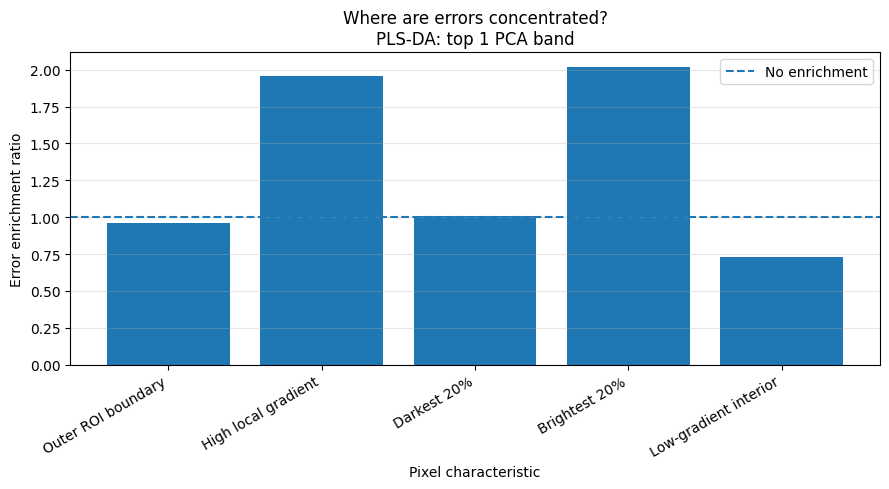

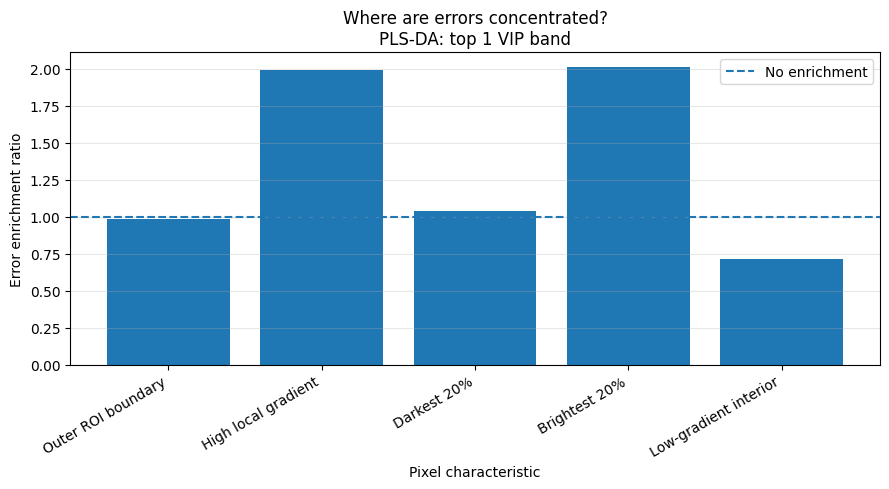

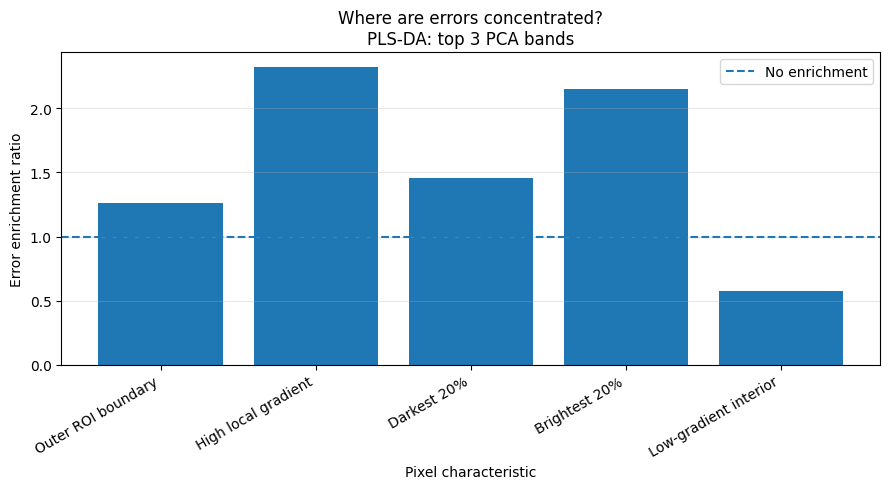

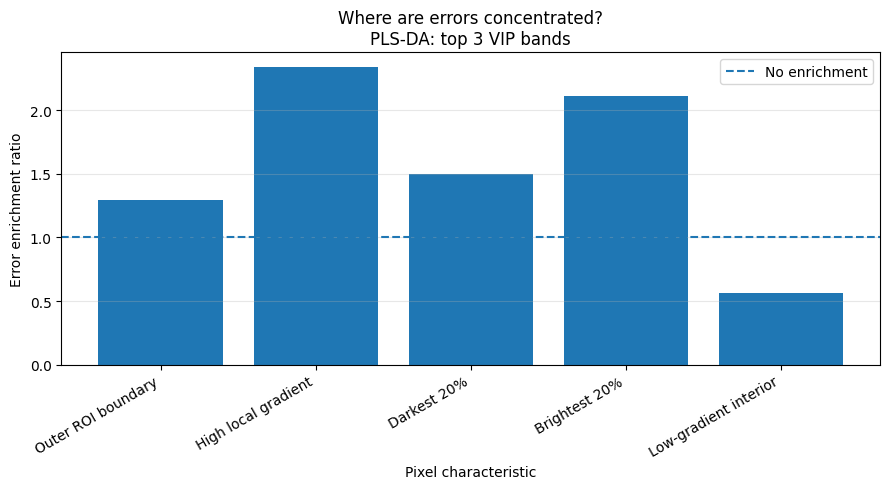

In [20]:
# --- Plot overall error enrichment by image characteristic ---

plot_characteristics = [
    "Outer ROI boundary",
    "High local gradient",
    "Darkest 20%",
    "Brightest 20%",
    "Low-gradient interior"
]


overall_enrichment_rows = []


for (
    model_label,
    characteristic
), group in spatial_characteristic_df[
    spatial_characteristic_df[
        "Characteristic"
    ].isin(
        plot_characteristics
    )
].groupby(
    [
        "Model",
        "Characteristic"
    ]
):

    overall_enrichment_rows.append({
        "Model": model_label,
        "Characteristic": characteristic,
        "Mean enrichment": group[
            "Error enrichment"
        ].mean(),
        "Median enrichment": group[
            "Error enrichment"
        ].median()
    })


overall_enrichment_df = pd.DataFrame(
    overall_enrichment_rows
)


display(
    overall_enrichment_df
)


for model_label in diagnostic_model_labels:

    plot_data = overall_enrichment_df[
        overall_enrichment_df["Model"]
        == model_label
    ].copy()


    plot_data["Characteristic"] = pd.Categorical(
        plot_data["Characteristic"],
        categories=plot_characteristics,
        ordered=True
    )


    plot_data = plot_data.sort_values(
        "Characteristic"
    )


    plt.figure(
        figsize=(9, 5)
    )


    plt.bar(
        plot_data[
            "Characteristic"
        ].astype(str),
        plot_data[
            "Mean enrichment"
        ]
    )


    plt.axhline(
        1.0,
        linestyle="--",
        linewidth=1.5,
        label="No enrichment"
    )


    plt.ylabel(
        "Error enrichment ratio"
    )

    plt.xlabel(
        "Pixel characteristic"
    )

    plt.title(
        f"Where are errors concentrated?\n"
        f"{model_label}"
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

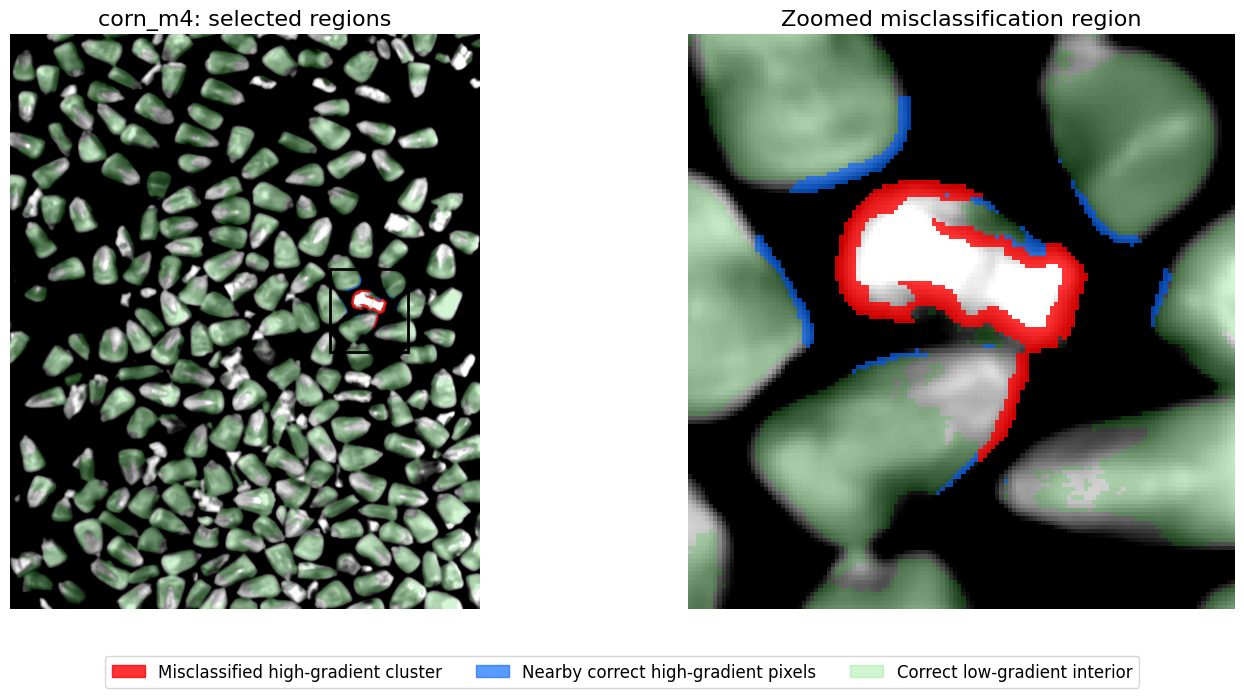

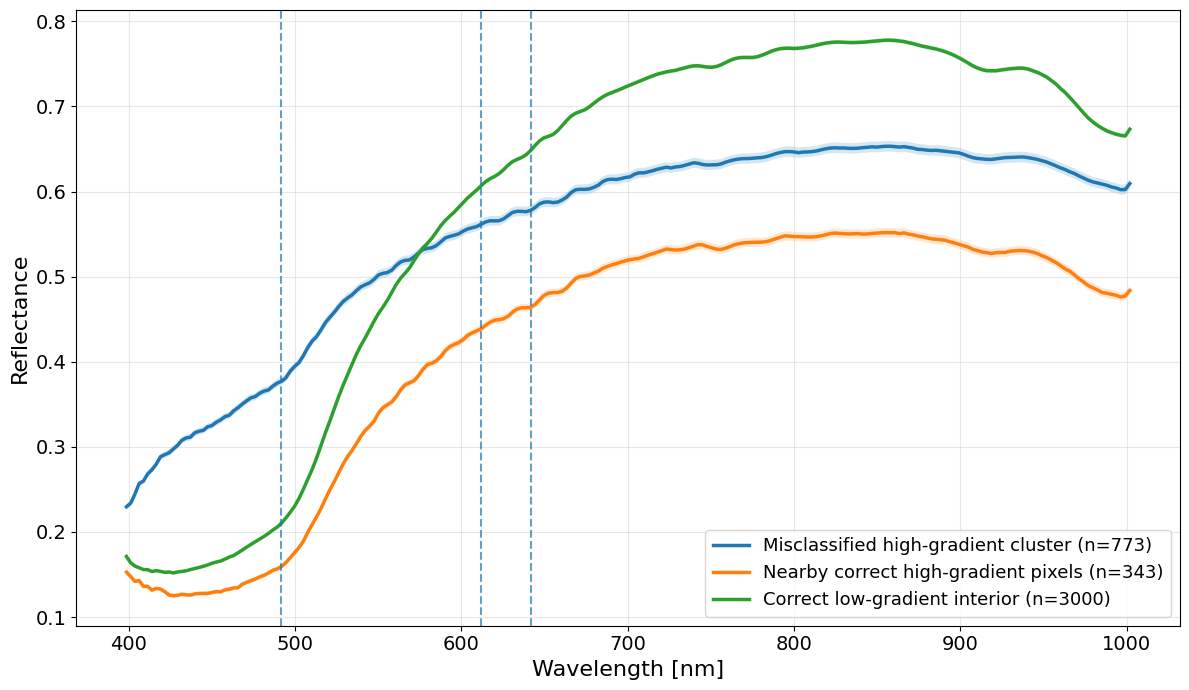

Selected wavelengths: [491.9 611.9 641.6] nm
Misclassified high-gradient cluster : 773 pixels
Nearby correct high-gradient pixels : 343 pixels
Correct low-gradient interior : 3000 pixels


In [21]:
# --- Detailed corn-medium top-three-PCA spectral case study ---

CASE_MODEL_LABEL = (
    "PLS-DA: top 3 PCA bands"
)

CASE_IMAGE_ID = "corn_m4"

HIGH_GRADIENT_QUANTILE = 0.80
NEARBY_DILATION_ITERATIONS = 20
ZOOM_PADDING = 35
MAX_SPECTRA_PER_REGION = 3000

RANDOM_SEED = 42


case_result = next(
    result
    for result in results_plsda_bands
    if result["label"]
    == CASE_MODEL_LABEL
)


case_row = files_split[
    files_split["sample_name"]
    == CASE_IMAGE_ID
].iloc[0]


filepath = case_row[
    "filepath_FX10"
]

true_label = case_row[
    "variety"
]

size = case_row[
    "size"
]


hcube, current_wavelengths, darkref, whiteref = (
    load_cube(
        filepath
    )
)


hcube_c = hcube[
    75:1025,
    100:875,
    :
]


foreground_mask = (
    build_foreground_mask_auto(
        hcube_c,
        size=size,
        true_label=true_label
    )
    > 0
)


y_coords, x_coords = np.nonzero(
    foreground_mask
)


band_indices = np.asarray(
    case_result["band_indices"],
    dtype=int
)

train_mean = np.asarray(
    case_result["train_mean"]
)

model = case_result[
    "model"
]


X_selected = np.column_stack([
    hcube_c[
        y_coords,
        x_coords,
        band_index
    ]
    for band_index in band_indices
])


X_selected_mc = (
    X_selected
    - train_mean
)


prediction_scores = model.predict(
    X_selected_mc
)


predicted_labels = lb.classes_[
    np.argmax(
        prediction_scores,
        axis=1
    )
]


correct_vector = (
    predicted_labels
    == true_label
)


correct_map = np.zeros(
    foreground_mask.shape,
    dtype=bool
)

correct_map[
    y_coords,
    x_coords
] = correct_vector


error_map = (
    foreground_mask
    & ~correct_map
)


mean_image = hcube_c.mean(
    axis=2
)


gradient_x = sobel(
    mean_image,
    axis=1
)

gradient_y = sobel(
    mean_image,
    axis=0
)

gradient_magnitude = np.sqrt(
    gradient_x ** 2
    + gradient_y ** 2
)


gradient_threshold = np.quantile(
    gradient_magnitude[
        foreground_mask
    ],
    HIGH_GRADIENT_QUANTILE
)


high_gradient_mask = (
    foreground_mask
    & (
        gradient_magnitude
        >= gradient_threshold
    )
)


misclassified_high_gradient = (
    error_map
    & high_gradient_mask
)


labelled_error_regions, n_regions = (
    connected_component_label(
        misclassified_high_gradient
    )
)


component_sizes = np.bincount(
    labelled_error_regions.ravel()
)


if len(component_sizes) <= 1:
    raise ValueError(
        "No connected high-gradient error "
        "region was found."
    )


component_sizes[0] = 0


largest_component_label = int(
    np.argmax(
        component_sizes
    )
)


focal_error_mask = (
    labelled_error_regions
    == largest_component_label
)


nearby_area = binary_dilation(
    focal_error_mask,
    iterations=NEARBY_DILATION_ITERATIONS
)


nearby_correct_high_gradient = (
    nearby_area
    & correct_map
    & high_gradient_mask
)


correct_low_gradient_interior = (
    foreground_mask
    & correct_map
    & ~high_gradient_mask
)


region_masks = {
    "Misclassified high-gradient cluster": (
        focal_error_mask
    ),
    "Nearby correct high-gradient pixels": (
        nearby_correct_high_gradient
    ),
    "Correct low-gradient interior": (
        correct_low_gradient_interior
    )
}


rng = np.random.default_rng(
    RANDOM_SEED
)


region_spectra = {}


for region_name, region_mask in (
    region_masks.items()
):

    region_y, region_x = np.nonzero(
        region_mask
    )


    if len(region_y) == 0:

        region_spectra[
            region_name
        ] = None

        continue


    if (
        len(region_y)
        > MAX_SPECTRA_PER_REGION
    ):

        selected_indices = rng.choice(
            len(region_y),
            size=MAX_SPECTRA_PER_REGION,
            replace=False
        )

        region_y = region_y[
            selected_indices
        ]

        region_x = region_x[
            selected_indices
        ]


    region_spectra[
        region_name
    ] = hcube_c[
        region_y,
        region_x,
        :
    ]


focal_y, focal_x = np.nonzero(
    focal_error_mask
)


row_start = max(
    0,
    focal_y.min()
    - ZOOM_PADDING
)

row_stop = min(
    hcube_c.shape[0],
    focal_y.max()
    + ZOOM_PADDING
    + 1
)

column_start = max(
    0,
    focal_x.min()
    - ZOOM_PADDING
)

column_stop = min(
    hcube_c.shape[1],
    focal_x.max()
    + ZOOM_PADDING
    + 1
)


foreground_values = mean_image[
    foreground_mask
]


display_low, display_high = np.percentile(
    foreground_values,
    [2, 98]
)


display_image = np.clip(
    (
        mean_image
        - display_low
    )
    / (
        display_high
        - display_low
        + 1e-8
    ),
    0,
    1
)


region_overlay = np.zeros(
    (
        foreground_mask.shape[0],
        foreground_mask.shape[1],
        4
    ),
    dtype=float
)


region_overlay[
    focal_error_mask
] = [
    1.0,
    0.0,
    0.0,
    0.80
]


region_overlay[
    nearby_correct_high_gradient
] = [
    0.0,
    0.4,
    1.0,
    0.65
]


region_overlay[
    correct_low_gradient_interior
] = [
    0.0,
    0.8,
    0.0,
    0.18
]


# Figure 1: region overview + zoomed region
fig1, axes1 = plt.subplots(
    1,
    2,
    figsize=(15, 7)
)

axes1[0].imshow(
    display_image,
    cmap="gray"
)

axes1[0].imshow(
    region_overlay
)

zoom_rectangle = plt.Rectangle(
    (
        column_start,
        row_start
    ),
    column_stop - column_start,
    row_stop - row_start,
    fill=False,
    linewidth=2
)

axes1[0].add_patch(
    zoom_rectangle
)

axes1[0].set_title(
    f"{CASE_IMAGE_ID}: selected regions",
    fontsize=16
)
axes1[0].axis(
    "off"
)


axes1[1].imshow(
    display_image[
        row_start:row_stop,
        column_start:column_stop
    ],
    cmap="gray"
)

axes1[1].imshow(
    region_overlay[
        row_start:row_stop,
        column_start:column_stop,
        :
    ]
)

axes1[1].set_title(
    "Zoomed misclassification region",
    fontsize=16
)
axes1[1].axis(
    "off"
)

legend_handles = [
    mpatches.Patch(
        color=[
            1.0,
            0.0,
            0.0,
            0.80
        ],
        label=(
            "Misclassified "
            "high-gradient cluster"
        )
    ),
    mpatches.Patch(
        color=[
            0.0,
            0.4,
            1.0,
            0.65
        ],
        label=(
            "Nearby correct "
            "high-gradient pixels"
        )
    ),
    mpatches.Patch(
        color=[
            0.0,
            0.8,
            0.0,
            0.18
        ],
        label=(
            "Correct low-gradient "
            "interior"
        )
    )
]

fig1.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    fontsize=12
)

plt.tight_layout(
    rect=[
        0,
        0.10,
        1,
        1
    ]
)
plt.show()


# Figure 2: regional mean spectra
fig2, ax2 = plt.subplots(
    1,
    1,
    figsize=(12, 7)
)

for region_name, spectra in (
    region_spectra.items()
):

    if spectra is None:
        continue

    mean_spectrum = spectra.mean(
        axis=0
    )

    standard_error = (
        spectra.std(
            axis=0
        )
        / np.sqrt(
            len(spectra)
        )
    )

    ax2.plot(
        wavelengths,
        mean_spectrum,
        linewidth=2.5,
        label=(
            f"{region_name} "
            f"(n={len(spectra)})"
        )
    )

    ax2.fill_between(
        wavelengths,
        mean_spectrum
        - standard_error,
        mean_spectrum
        + standard_error,
        alpha=0.18
    )

for band_index in band_indices:

    ax2.axvline(
        wavelengths[
            band_index
        ],
        linestyle="--",
        alpha=0.7
    )

ax2.set_xlabel(
    "Wavelength [nm]",
    fontsize=16
)

ax2.set_ylabel(
    "Reflectance",
    fontsize=16
)

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=14
)

ax2.grid(
    alpha=0.3
)

ax2.legend(
    fontsize=13
)

plt.tight_layout()
plt.show()


print(
    "Selected wavelengths:",
    np.round(
        wavelengths[
            band_indices
        ],
        1
    ),
    "nm"
)


for region_name, spectra in (
    region_spectra.items()
):

    print(
        region_name,
        ":",
        0
        if spectra is None
        else len(spectra),
        "pixels"
    )